# Multi-Agent Debate — Analysis & Plots

Reads CSVs produced by `analyze.py` and generates paper-ready figures.

**Usage:** Run `python analyze.py --all` first, then run this notebook.

Found 6 experiments: ['accuracy_bss', 'baseline', 'binary_bss', 'bss', 'dss', 'random_bss']


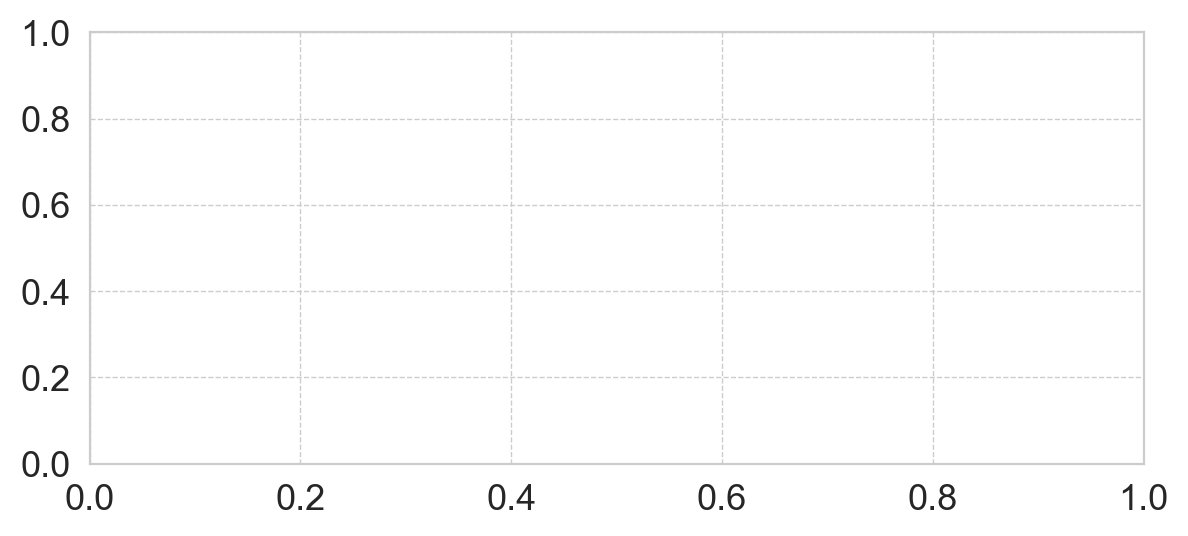

In [27]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np
import json, os
from pathlib import Path
from collections import OrderedDict

# ── Style (paper-ready) ───────────────────────────────────────────
plt.rcParams.update({
    # Font (LaTeX-like)
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    
    # Sizes tuned for 1-column figures
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 11,

    # Figure resolution
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    # Lines
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
    "lines.linewidth": 1.5,
})

sns.set_style("whitegrid", {
    "grid.linestyle": "--",
    "grid.alpha": 0.3
})

PALETTE = OrderedDict([
    ("baseline",     "#4A90E2"),
    ("bss",          "#E24A4A"),
    ("dss",          "#50C878"),
    ("binary_bss",   "#F5A623"),
    ("accuracy_bss", "#9B59B6"),
    ("random_bss",   "#95A5A6"),
])
    
fig, ax = plt.subplots(figsize=(6.8, 2.8))  # wide + compact


# plt.rcParams.update({
#     "font.size": 14,
#     "axes.titlesize": 16,
#     "axes.labelsize": 16,
#     "xtick.labelsize": 13,
#     "ytick.labelsize": 13,
#     "legend.fontsize": 12,
#     "figure.dpi": 150,
#     "savefig.dpi": 300,
#     "savefig.bbox": "tight",
# })
# sns.set_style("whitegrid")

# PALETTE = OrderedDict([
#     ("baseline",     "#4A90E2"),
#     ("bss",          "#E24A4A"),
#     ("dss",          "#50C878"),
#     ("binary_bss",   "#F5A623"),
#     ("accuracy_bss", "#9B59B6"),
#     ("random_bss",   "#95A5A6"),
# ])

NICE_NAMES = {
    "baseline": "Baseline",
    "bss": "BSS",
    "dss": "DSS",
    "binary_bss": "Binary BSS",
    "accuracy_bss": "Acc BSS",
    "random_bss": "Random BSS",
}

MODEL_ORDER = ["llama3b", "llama8b", "qwen3b", "qwen7b", "qwen14b", "qwen32b", "majority"]

MODEL_PALETTE = OrderedDict([
    ("llama3b",  "#E24A4A"),
    ("llama8b",  "#F5A623"),
    ("qwen3b",   "#50C878"),
    ("qwen7b",   "#4A90E2"),
    ("qwen14b",  "#9B59B6"),
    ("qwen32b",  "#2C3E50"),
    ("majority", "#95A5A6"),
])

def exp_color(exp):
    return PALETTE.get(exp, "#333333")

def exp_colors(exps):
    return [exp_color(e) for e in exps]

def model_color(model):
    return MODEL_PALETTE.get(model, "#333333")

def model_colors(models):
    return [model_color(m) for m in models]

# ═══════════════════════════════════════════════════════════════════
# CONFIG — edit these paths to point at your data
# ═══════════════════════════════════════════════════════════════════
LOGS_DIR = Path("logs")           # root dir containing experiment folders
FIGS_DIR = Path("figures")        # where plots are saved

# Option 1: auto-discover all experiments that have analysis/ output
# EXPERIMENTS = None

# Option 2: list exactly the experiments you want, in the order you want
# EXPERIMENTS = ["baseline", "bss", "dss"]

# Option 3: point at arbitrary paths (keys become experiment names in plots)
# EXPERIMENT_PATHS = {
#     "baseline_v2": Path("/some/other/place/baseline/analysis"),
#     "bss_250":     Path("logs/bss_250/analysis"),
# }

EXPERIMENTS = None     # set to a list to override auto-discovery
EXPERIMENT_PATHS = {}  # set to a dict to use arbitrary paths
# ═══════════════════════════════════════════════════════════════════

FIGS_DIR.mkdir(exist_ok=True)

# Legend placement: centered above the axes (heatmap cells keep defaults — no separate legend)
LEGEND_KW = dict(loc="upper center", bbox_to_anchor=(0.5, 1.14), framealpha=0.95)
LEGEND_FIG_KW = dict(loc="upper center", bbox_to_anchor=(0.5, 1.0), framealpha=0.95)

if EXPERIMENT_PATHS:
    EXPERIMENTS = list(EXPERIMENT_PATHS.keys())
elif EXPERIMENTS is None:
    EXPERIMENTS = [d for d in sorted(os.listdir(LOGS_DIR))
                   if (LOGS_DIR / d / "analysis" / "accuracy.csv").exists()]

def _analysis_dir(exp):
    """Return the analysis directory for an experiment name."""
    if exp in EXPERIMENT_PATHS:
        return Path(EXPERIMENT_PATHS[exp])
    return LOGS_DIR / exp / "analysis"

print(f"Found {len(EXPERIMENTS)} experiments: {EXPERIMENTS}")


In [28]:
# ── Load all analysis CSVs into dicts ─────────────────────────────
accuracy = {}
flips = {}
flip_raw = {}
influence = {}
round_traj = {}
sycophancy = {}
subject_acc = {}
summaries = {}
knowledge_acc = {}
convergence = {}
bss_scores = {}
round1_final = {}
stability = {}

for exp in EXPERIMENTS:
    d = _analysis_dir(exp)
    accuracy[exp] = pd.read_csv(d / "accuracy.csv")
    if (d / "flip_summary.csv").exists():
        flips[exp] = pd.read_csv(d / "flip_summary.csv")
    if (d / "flips.csv").exists():
        flip_raw[exp] = pd.read_csv(d / "flips.csv")
    if (d / "influence.csv").exists():
        influence[exp] = pd.read_csv(d / "influence.csv")
    if (d / "round_trajectory.csv").exists():
        round_traj[exp] = pd.read_csv(d / "round_trajectory.csv")
    if (d / "sycophancy_summary.csv").exists():
        sycophancy[exp] = pd.read_csv(d / "sycophancy_summary.csv")
    if (d / "subject_accuracy.csv").exists():
        subject_acc[exp] = pd.read_csv(d / "subject_accuracy.csv")
    if (d / "summary.json").exists():
        with open(d / "summary.json") as f:
            summaries[exp] = json.load(f)
    if (d / "knowledge_gated_accuracy.csv").exists():
        knowledge_acc[exp] = pd.read_csv(d / "knowledge_gated_accuracy.csv")
    if (d / "convergence.csv").exists():
        convergence[exp] = pd.read_csv(d / "convergence.csv")
    bss_path = d / "bss_scores.csv"
    if bss_path.exists():
        try:
            bss_scores[exp] = pd.read_csv(bss_path)
        except pd.errors.EmptyDataError:
            pass
    if (d / "round1_vs_final.csv").exists():
        round1_final[exp] = pd.read_csv(d / "round1_vs_final.csv")
    if (d / "stability.csv").exists():
        stability[exp] = pd.read_csv(d / "stability.csv")

print("Loaded.")

Loaded.


## 1. Cross-Experiment Accuracy Comparison

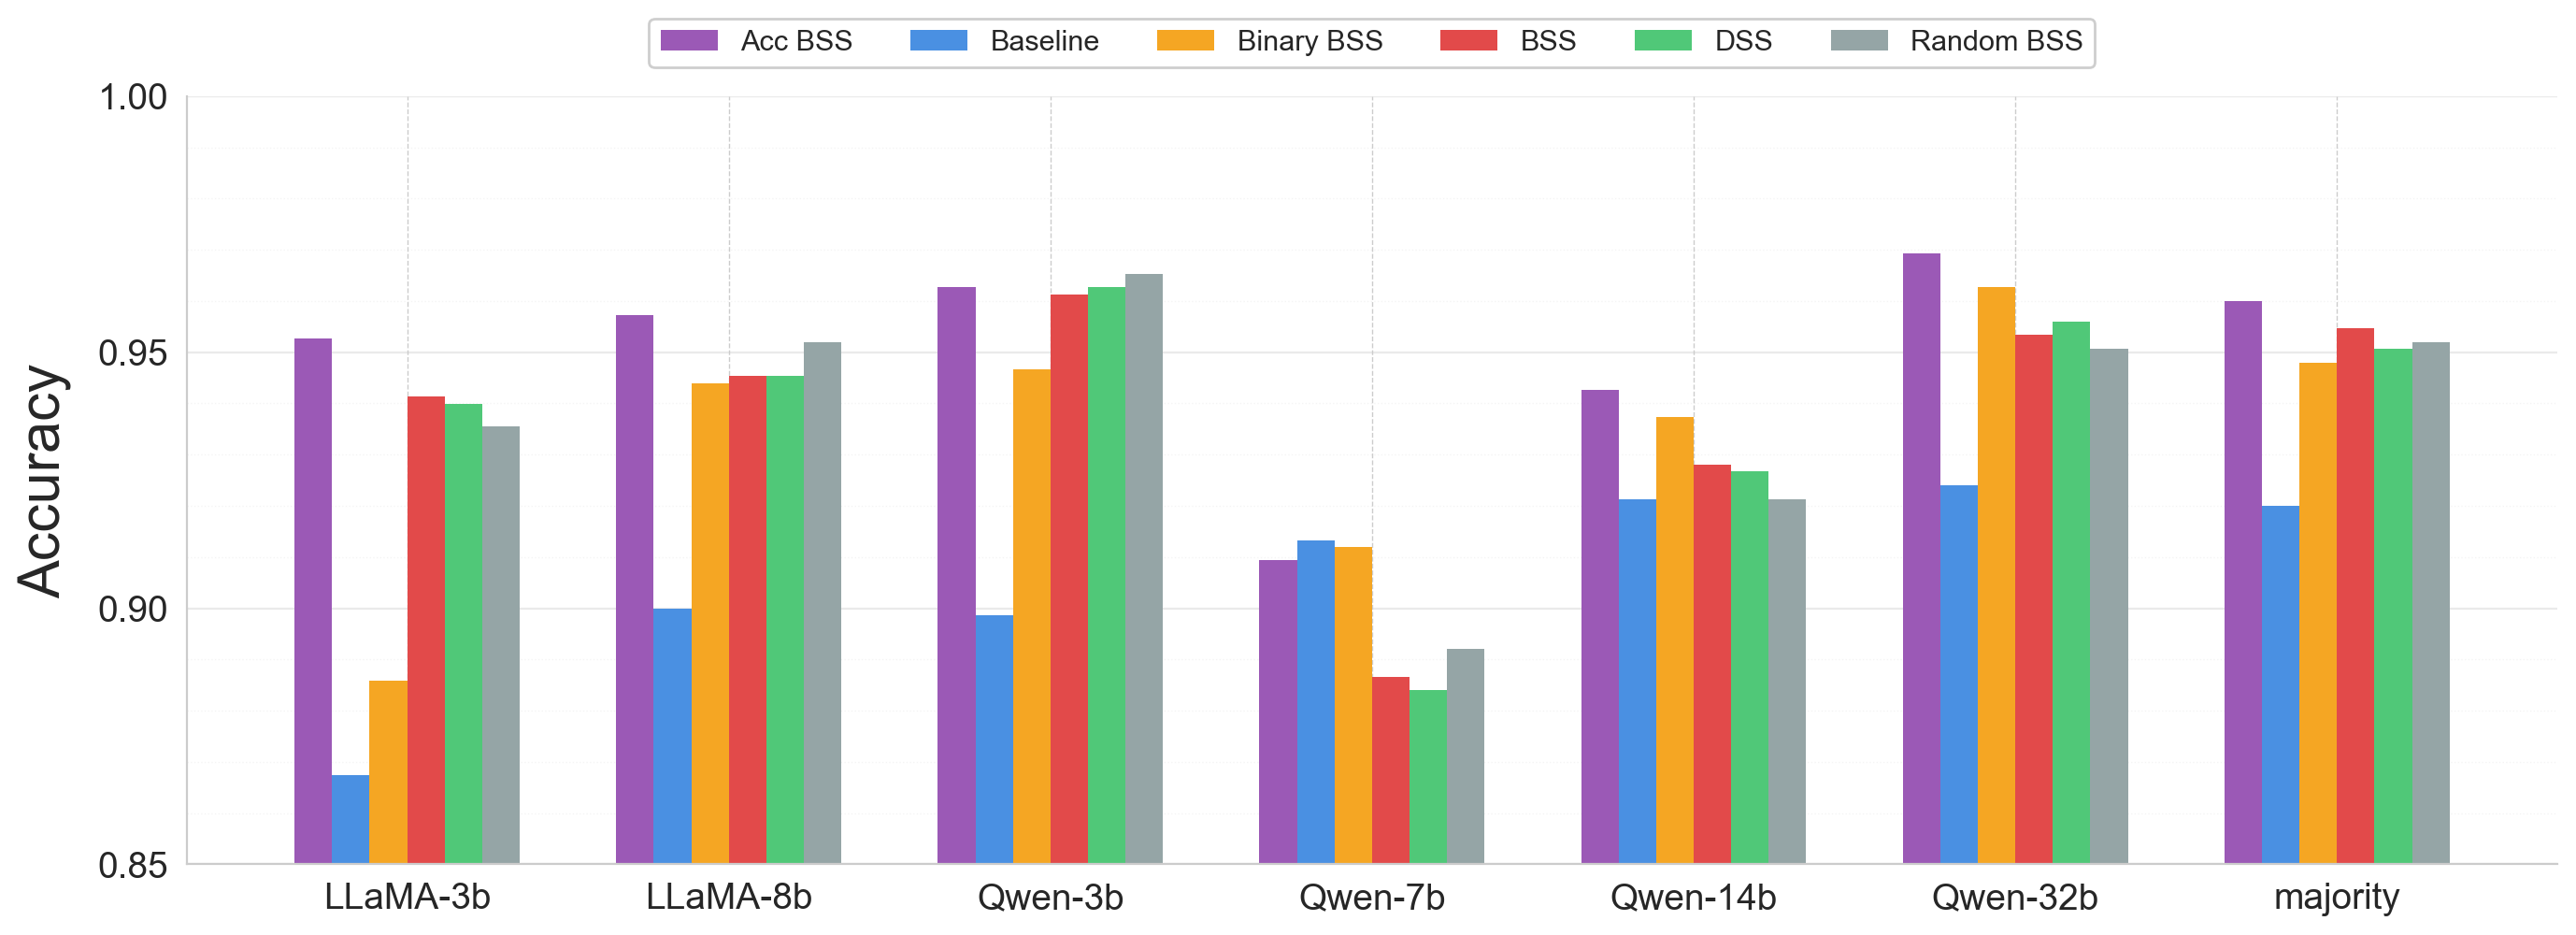

In [55]:
rows = []
for exp in EXPERIMENTS:
    for _, r in accuracy[exp].iterrows():
        rows.append({"experiment": exp, "model": r["model"],
                     "accuracy": r["accuracy"], "null_rate": r["null_rate"]})

comp_df = pd.DataFrame(rows)
comp_df["model"] = pd.Categorical(comp_df["model"], categories=MODEL_ORDER, ordered=True)
comp_df = comp_df.sort_values(["model", "experiment"])

fig, ax = plt.subplots(figsize=(14, 6.5))
models_in_data = [m for m in MODEL_ORDER if m in comp_df["model"].unique()]
x = np.arange(len(models_in_data))
n_exp = len(EXPERIMENTS)
width = 0.7 / n_exp   # slightly tighter

for i, exp in enumerate(EXPERIMENTS):
    exp_data = comp_df[comp_df["experiment"] == exp].set_index("model")
    vals = [exp_data.loc[m, "accuracy"] if m in exp_data.index else np.nan for m in models_in_data]

    bars = ax.bar(
        x + i * width,
        vals,
        width,
        label=NICE_NAMES.get(exp, exp),
        color=exp_color(exp),
        edgecolor="none"
    )

ax.set_ylabel("Accuracy", fontsize=22, labelpad=10)
ax.set_xticks(x + width * (n_exp - 1) / 2)
ax.set_xticklabels([m.replace("llama", "LLaMA-").replace("qwen", "Qwen-") for m in models_in_data], fontsize=14)

ax.set_ylim(0.85, 1.0)   # tighter range → more visible differences
ax.set_yticks([0.85, 0.9, 0.95, 1.0])
ax.tick_params(labelsize=14)

# Fine-grained y-axis ticks for better granularity
ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.01))

# Enhanced gridlines (major and minor)
ax.grid(True, which="major", axis="y", linestyle="-", alpha=0.4, linewidth=0.8, zorder=0)
ax.grid(True, which="minor", axis="y", linestyle=":", alpha=0.2, linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

sns.despine(left=False, bottom=False)

ax.legend(ncol=len(EXPERIMENTS), loc="upper center", bbox_to_anchor=(0.5, 1.12), framealpha=0.95)

fig.tight_layout(rect=[0, 0, 1, 0.82])


# for i, exp in enumerate(EXPERIMENTS):
#     exp_data = comp_df[comp_df["experiment"] == exp].set_index("model")
#     vals = [exp_data.loc[m, "accuracy"] if m in exp_data.index else 0 for m in models_in_data]
#     ax.bar(x + i * width, vals, width, label=NICE_NAMES.get(exp, exp),
#            color=exp_color(exp), edgecolor="white", linewidth=0.5)

# ax.set_xticks(x + width * (n_exp - 1) / 2)
# ax.set_xticklabels(models_in_data)
# ax.set_ylabel("Final Accuracy")
# ax.legend(ncol=len(EXPERIMENTS), **LEGEND_KW)
# ax.set_ylim(0.5, 1.0)
# ax.axhline(0.5, color="grey", ls="--", lw=0.5)
# sns.despine()
# fig.tight_layout(rect=[0, 0, 1, 0.88])
# fig.savefig(FIGS_DIR / "accuracy_comparison.pdf")
# fig.savefig(FIGS_DIR / "accuracy_comparison.png")
# plt.show()


In [31]:
# Print the numbers as a clean table
pivot = comp_df.pivot_table(index="experiment", columns="model", values="accuracy")
pivot = pivot[[m for m in MODEL_ORDER if m in pivot.columns]]
# Rename columns to match chart labels
pivot.columns = [c.replace("llama", "LLaMA-").replace("qwen", "Qwen-") for c in pivot.columns]
pivot.index.name = None  # Remove the "experiment" label from the index
display(pivot.round(4).style.background_gradient(cmap="RdYlGn", axis=None, vmin=0.6, vmax=1.0))

C:\Users\Acer\AppData\Local\Temp\ipykernel_21468\593167172.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = comp_df.pivot_table(index="experiment", columns="model", values="accuracy")


,LLaMA-3b,LLaMA-8b,Qwen-3b,Qwen-7b,Qwen-14b,Qwen-32b,majority
accuracy_bss,0.952700,0.957300,0.962700,0.909300,0.942700,0.969300,0.960000
baseline,0.867400,0.900000,0.898700,0.913300,0.921300,0.924000,0.920000
binary_bss,0.885800,0.944000,0.946700,0.912000,0.937300,0.962700,0.948000
bss,0.941400,0.945300,0.961300,0.886700,0.928000,0.953300,0.954700
dss,0.939800,0.945300,0.962700,0.884000,0.926700,0.956000,0.950700
random_bss,0.935400,0.952000,0.965300,0.892000,0.921300,0.950700,0.952000


## 4. Influence Heatmaps

C:\Users\Acer\AppData\Local\Temp\ipykernel_21468\2420144422.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.04, 0.06, 0.98, 0.94])


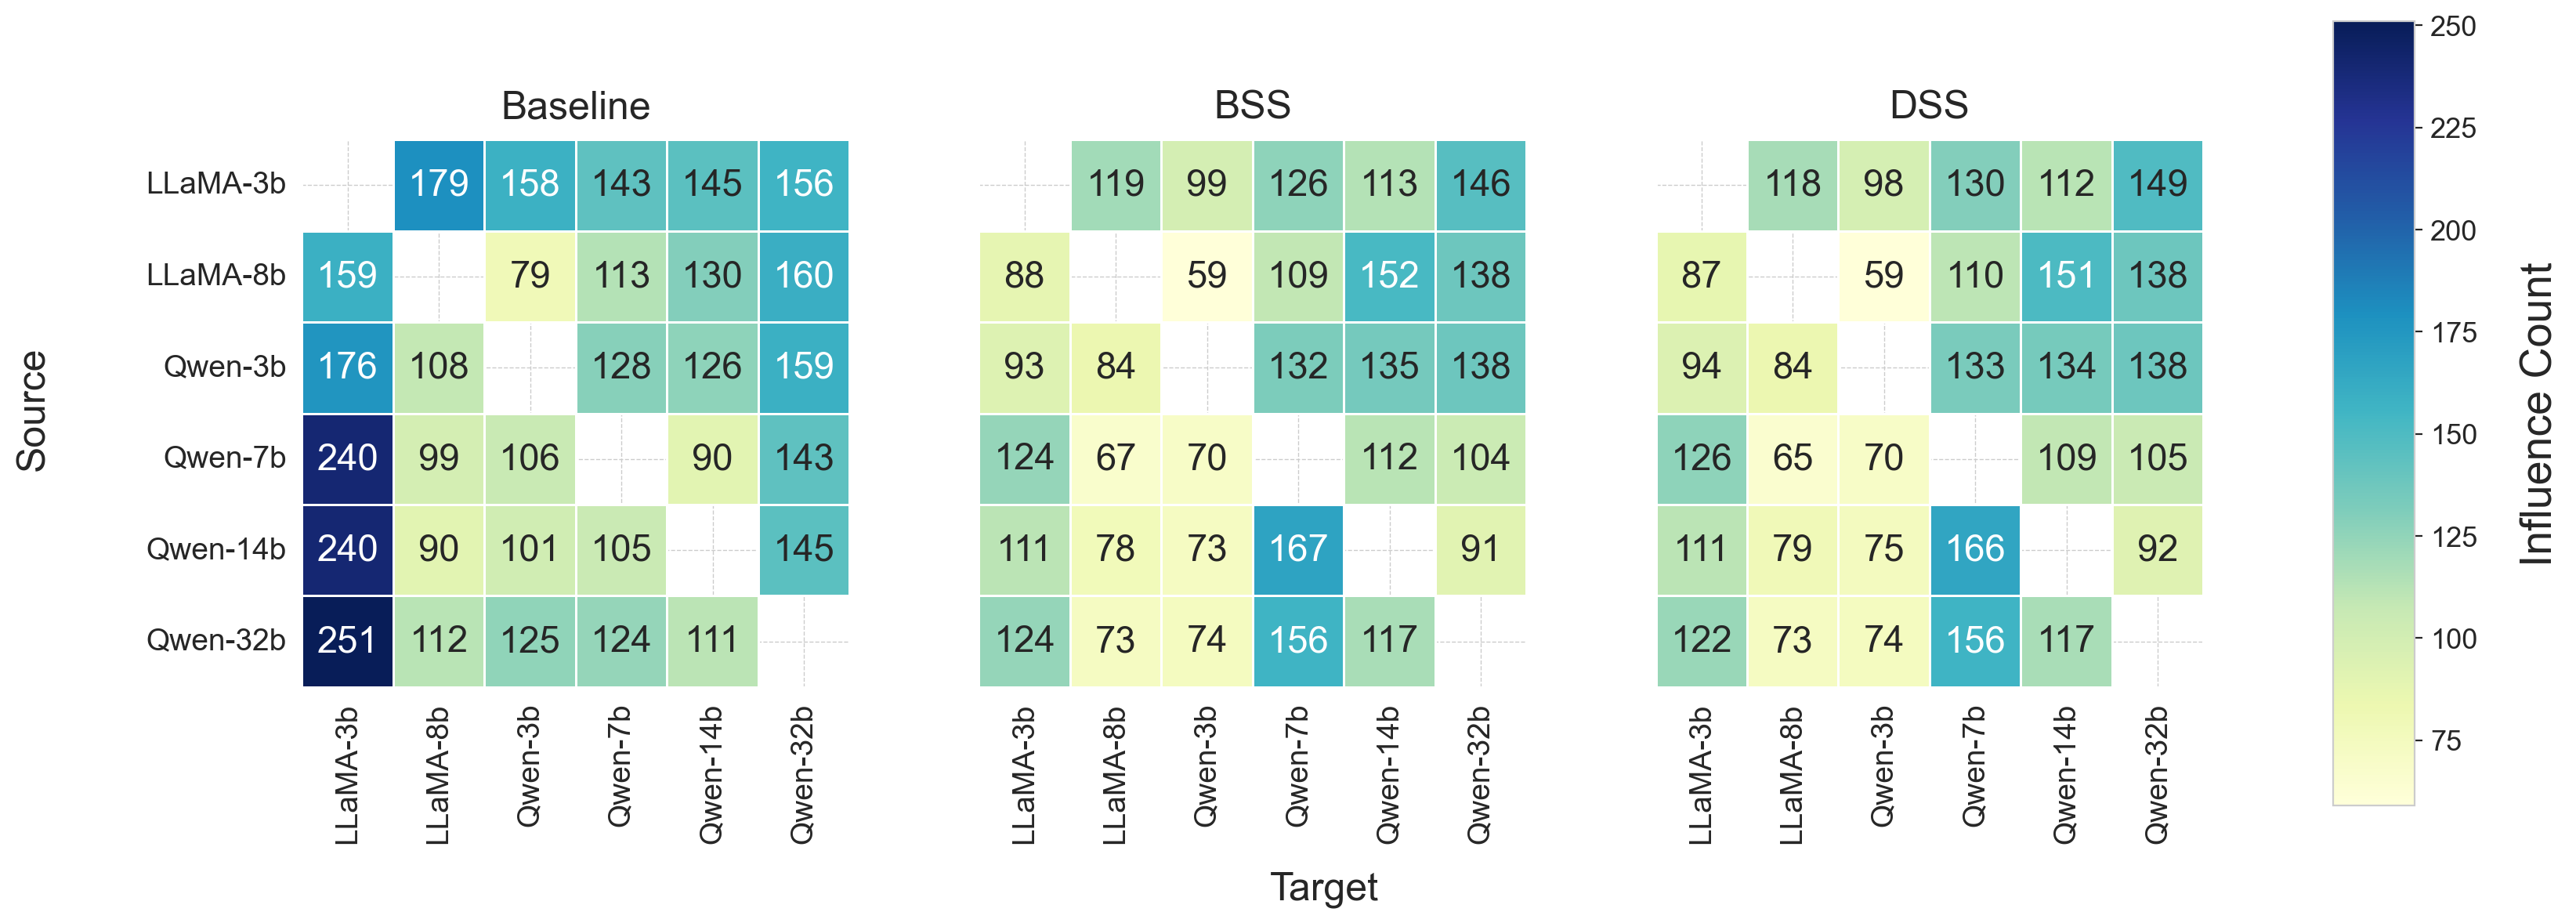

In [37]:
preferred = ["baseline", "bss", "dss"]
exps_to_show = [e for e in preferred if e in influence]
if not exps_to_show:
    exps_to_show = [e for e in EXPERIMENTS if e in influence][:3]

from matplotlib.gridspec import GridSpec

if exps_to_show:
    # Build matrices and a common model order + color scale
    matrices = []
    models_union = []
    for exp in exps_to_show:
        idf = influence[exp]
        if idf.empty:
            matrices.append(None)
            continue
        ml = sorted(set(idf["source"]) | set(idf["target"]))
        ml = [m for m in MODEL_ORDER if m in ml and m != "majority"]
        models_union.extend(ml)
        mat = pd.DataFrame(np.nan, index=ml, columns=ml)
        for _, r in idf.iterrows():
            if r["source"] in ml and r["target"] in ml:
                mat.loc[r["source"], r["target"]] = r["count"]
        for i, m in enumerate(ml):
            mat.iloc[i, i] = np.nan  # no self-influence on diagonal
        matrices.append(mat)

    models_list = [m for m in MODEL_ORDER if m in set(models_union) and m != "majority"]
    for j in range(len(matrices)):
        if matrices[j] is None:
            continue
        matrices[j] = matrices[j].reindex(index=models_list, columns=models_list)

    vals = np.concatenate([m.values.ravel() for m in matrices if m is not None])
    vals = vals[~np.isnan(vals)]
    vmin, vmax = (float(vals.min()), float(vals.max())) if len(vals) else (0.0, 1.0)

    n = len(exps_to_show)
    # Three equal-width heatmap panels + separate colorbar column (same size for all heatmaps)
    fig = plt.figure(figsize=(5.4 * n + 1.2, 6.5))
    gs = GridSpec(1, n + 1, figure=fig, width_ratios=[1] * n + [0.15], wspace=0.30)
    axes = [fig.add_subplot(gs[0, j]) for j in range(n)]
    cax = fig.add_subplot(gs[0, n])
    cbar_mappable = None

    for idx, exp in enumerate(exps_to_show):
        ax = axes[idx]
        mat = matrices[idx]
        if mat is None:
            ax.set_axis_off()
            continue
        mask = np.isnan(mat.values.astype(float))
        hm = sns.heatmap(
            mat.astype(float), ax=ax, annot=True, fmt=".0f",
            cmap="YlGnBu", mask=mask, linewidths=1, linecolor="white",
            square=True, annot_kws={"size": 17},
            vmin=vmin, vmax=vmax,
            cbar=False,
        )
        cbar_mappable = hm.collections[0]
        ax.set_title(NICE_NAMES.get(exp, exp), fontsize=18, pad=10)
        ax.set_xlabel("")
        ax.set_ylabel("")
        
        # Format model names to match chart labels (llama3b → LLaMA-3b, qwen3b → Qwen-3b)
        x_labels = [label.get_text().replace("llama", "LLaMA-").replace("qwen", "Qwen-") 
                    for label in ax.get_xticklabels()]
        y_labels = [label.get_text().replace("llama", "LLaMA-").replace("qwen", "Qwen-") 
                    for label in ax.get_yticklabels()]
        ax.set_xticklabels(x_labels, fontsize=14, rotation=90, ha="center")
        
        if idx == 0:
            ax.set_yticklabels(y_labels, fontsize=14)
        else:
            ax.set_yticklabels([])

    fig.supylabel("Source", fontsize=18, x=0.02)
    fig.supxlabel("Target", fontsize=18, y=0.01)

    if cbar_mappable is not None:
        cbar = fig.colorbar(cbar_mappable, cax=cax)
        cbar.set_label("Influence Count", fontsize=20, labelpad=20)
        cbar.ax.tick_params(labelsize=13)

    fig.tight_layout(rect=[0.04, 0.06, 0.98, 0.94])
    fig.savefig(FIGS_DIR / "influence_heatmaps.pdf")
    fig.savefig(FIGS_DIR / "influence_heatmaps.png")
    plt.show()


## 5. Round-by-Round Accuracy Trajectory

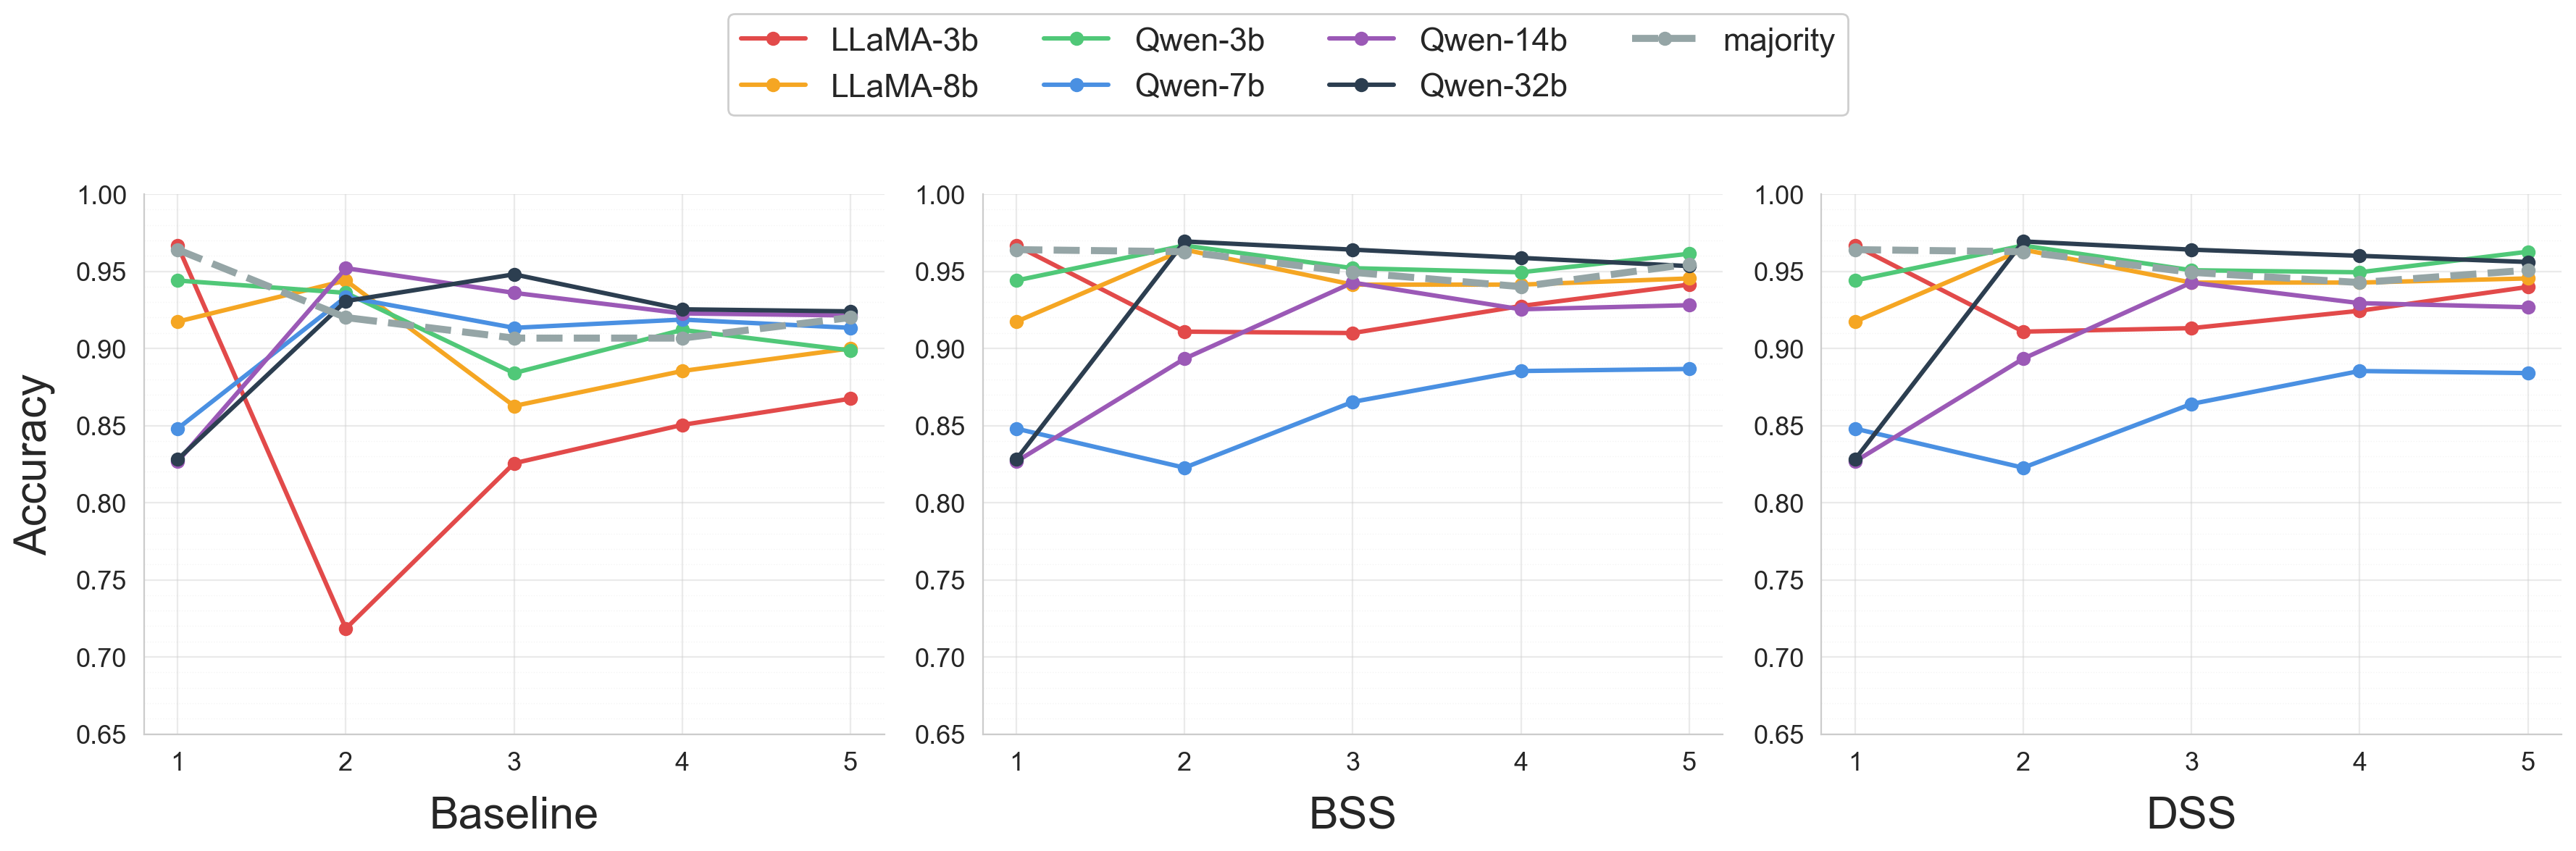

In [82]:
exps_traj = [e for e in ["baseline", "bss", "dss"] if e in round_traj]
if not exps_traj:
    exps_traj = list(round_traj.keys())[:3]

if exps_traj:
    fig, axes = plt.subplots(1, len(exps_traj), figsize=(6 * len(exps_traj), 6), squeeze=False)
    axes = axes[0]

    for idx, exp in enumerate(exps_traj):
        ax = axes[idx]
        df = round_traj[exp]
        for model in MODEL_ORDER:
            mdf = df[df["model"] == model]
            if mdf.empty:
                continue
            ls = "--" if model == "majority" else "-"
            lw = 3.5 if model == "majority" else 2.2  # Sharper, thicker lines
            model_display = model.replace("llama", "LLaMA-").replace("qwen", "Qwen-")
            ax.plot(mdf["round"], mdf["accuracy"], ls, lw=lw, label=model_display,
                    marker="o", ms=6, color=model_color(model), antialiased=True)
        
        ax.set_xlabel(NICE_NAMES.get(exp, exp), fontsize=22, labelpad=10)
        ax.set_ylabel("Accuracy" if idx == 0 else "", fontsize=22, labelpad=10)
        ax.set_ylim(0.65, 1.0)
        
        # Fine-grained y-axis ticks (0.05 intervals for better granularity)
        ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
        ax.yaxis.set_minor_locator(plt.MultipleLocator(0.01))
        
        # Add minor gridlines for better readability
        ax.grid(True, which="major", alpha=0.4, linestyle="-", linewidth=0.8, zorder=0)
        ax.grid(True, which="minor", alpha=0.2, linestyle=":", linewidth=0.5, zorder=0)
        ax.set_axisbelow(True)
        
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.tick_params(labelsize=13, length=5, width=1.2)

    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=4, fontsize=16, **LEGEND_FIG_KW)

    sns.despine()
    fig.tight_layout(rect=[0, 0, 1, 0.82])
    fig.savefig(FIGS_DIR / "round_trajectory.pdf")
    fig.savefig(FIGS_DIR / "round_trajectory.png")
    plt.show()


## 6. Post-Discussion Sycophancy

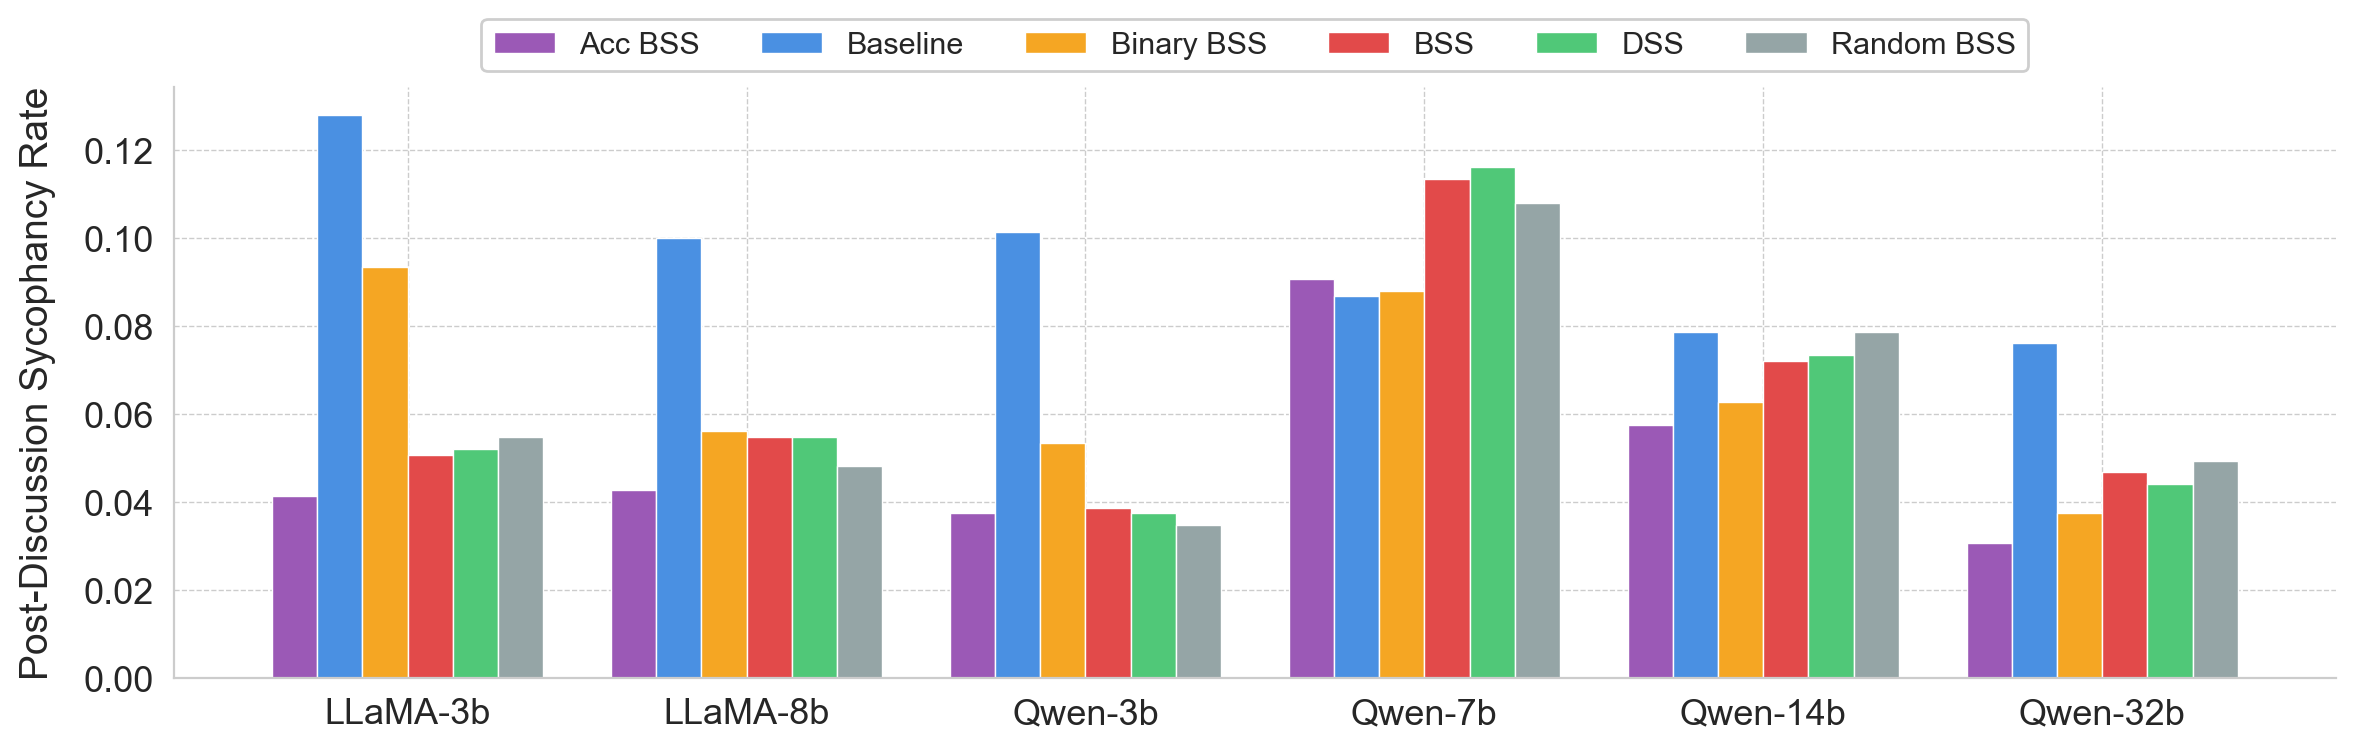

In [53]:
syco_rows = []
for exp in EXPERIMENTS:
    if exp in sycophancy:
        df = sycophancy[exp].copy()
        df["experiment"] = exp
        syco_rows.append(df)

if syco_rows:
    all_syco = pd.concat(syco_rows, ignore_index=True)
    avg_syco = all_syco.groupby(["experiment", "model"])["syco_rate"].mean().reset_index()
    avg_syco["model"] = pd.Categorical(avg_syco["model"],
                                        categories=[m for m in MODEL_ORDER if m != "majority"],
                                        ordered=True)

    fig, ax = plt.subplots(figsize=(12, 5))
    models_list = [m for m in MODEL_ORDER if m != "majority" and m in avg_syco["model"].unique()]
    x = np.arange(len(models_list))
    n_exp = len(EXPERIMENTS)
    width = 0.8 / n_exp

    for i, exp in enumerate(EXPERIMENTS):
        edf = avg_syco[avg_syco["experiment"] == exp].set_index("model")
        vals = [edf.loc[m, "syco_rate"] if m in edf.index else 0 for m in models_list]
        ax.bar(x + i * width, vals, width, label=NICE_NAMES.get(exp, exp),
               color=exp_color(exp), edgecolor="white", linewidth=0.5)

    ax.set_xticks(x + width * (n_exp - 1) / 2)
    ax.set_xticklabels([m.replace("llama", "LLaMA-").replace("qwen", "Qwen-") for m in models_list], fontsize=13)
    ax.set_ylabel("Post-Discussion Sycophancy Rate", fontsize=14, labelpad=10)
    ax.tick_params(labelsize=13)
    ax.legend(ncol=len(EXPERIMENTS), **LEGEND_KW)
    sns.despine()
    fig.tight_layout(rect=[0, 0, 1, 0.82])
    fig.savefig(FIGS_DIR / "sycophancy_comparison.pdf")
    fig.savefig(FIGS_DIR / "sycophancy_comparison.png")
    plt.show()


## 10. BSS Score vs Accuracy Delta (Core Hypothesis Test)

Does injecting sycophancy scores help more for models that *are* more sycophantic? This is the central claim of the paper.

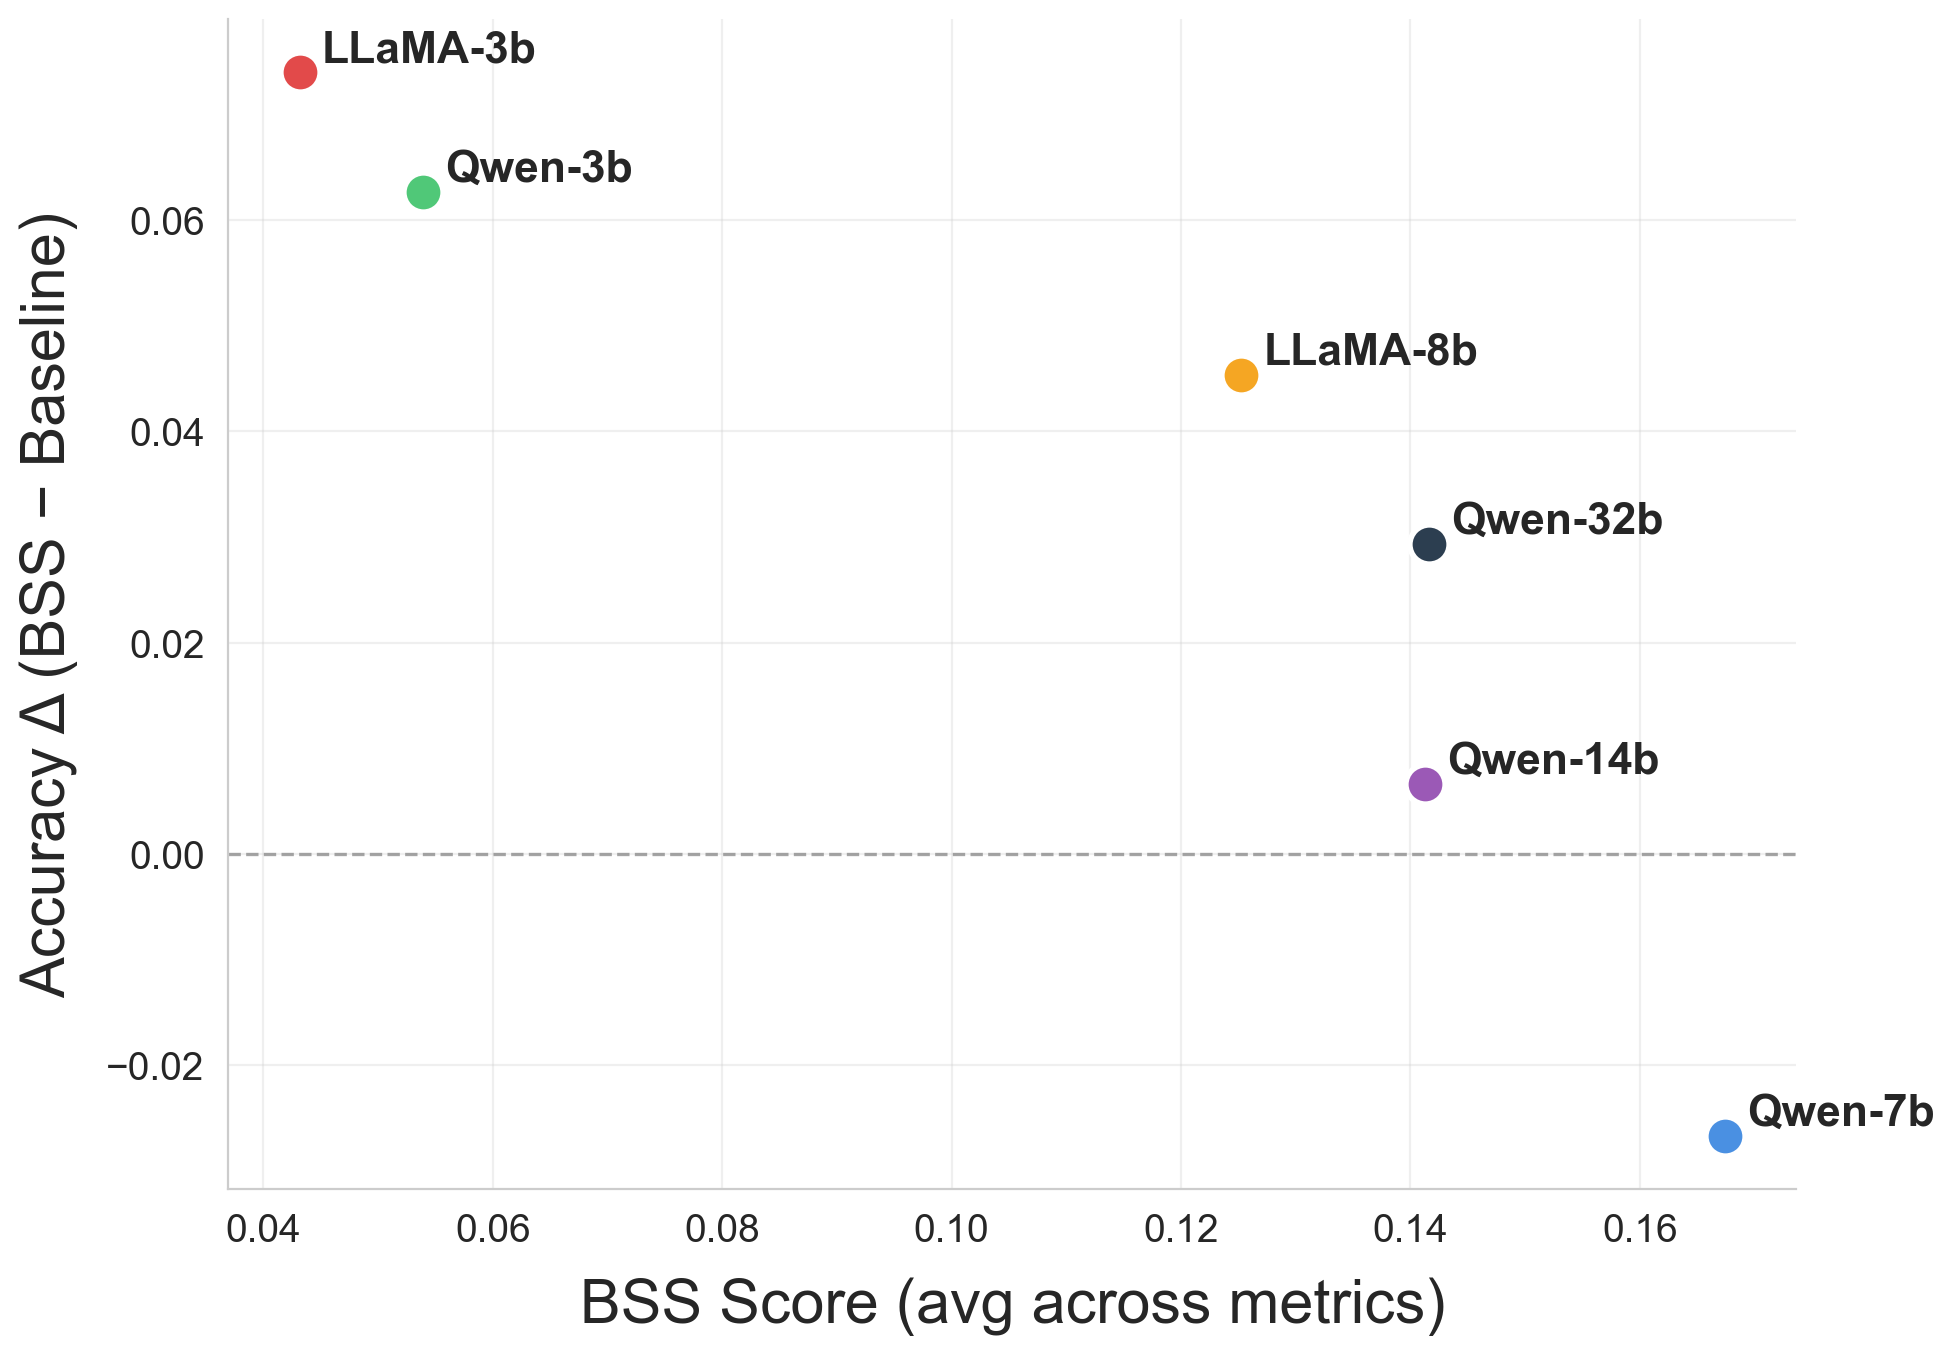

In [58]:
if "baseline" in accuracy and "bss" in accuracy and "bss" in bss_scores:
    base_acc = accuracy["baseline"].set_index("model")["accuracy"]
    bss_acc = accuracy["bss"].set_index("model")["accuracy"]
    scores_df = bss_scores["bss"]

    avg_bss = scores_df.groupby("model")["bss_score"].mean()

    models_both = [m for m in avg_bss.index if m in base_acc.index and m in bss_acc.index and m != "majority"]
    scatter_data = pd.DataFrame({
        "model": models_both,
        "bss_score": [avg_bss[m] for m in models_both],
        "delta": [(bss_acc[m] - base_acc[m]) for m in models_both],
    })

    fig, ax = plt.subplots(figsize=(10, 7))
    for _, row in scatter_data.iterrows():
        ax.scatter(row["bss_score"], row["delta"],
                   s=200, c=model_color(row["model"]), edgecolors="white", linewidth=2, zorder=5)
        model_display = row["model"].replace("llama", "LLaMA-").replace("qwen", "Qwen-")
        ax.annotate(model_display, (row["bss_score"], row["delta"]),
                    textcoords="offset points", xytext=(8, 4), fontsize=16, fontweight="bold")

    ax.axhline(0, color="grey", ls="--", lw=1.2, alpha=0.7)
    
    ax.set_xlabel("BSS Score (avg across metrics)", fontsize=22, labelpad=10)
    ax.set_ylabel("Accuracy Δ (BSS − Baseline)", fontsize=22, labelpad=10)
    
    # Fine-grained grid
    ax.grid(True, which="major", alpha=0.3, linestyle="-", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    
    # Enhanced tick styling
    ax.tick_params(labelsize=14, length=5, width=1.2)
    
    sns.despine()
    fig.tight_layout()
    fig.savefig(FIGS_DIR / "bss_score_vs_delta.pdf")
    fig.savefig(FIGS_DIR / "bss_score_vs_delta.png")
    plt.show()
else:
    print("Need both baseline and bss experiments with bss_scores.csv to plot this.")


## 11. Per-Subject Accuracy Delta (BSS − Baseline)

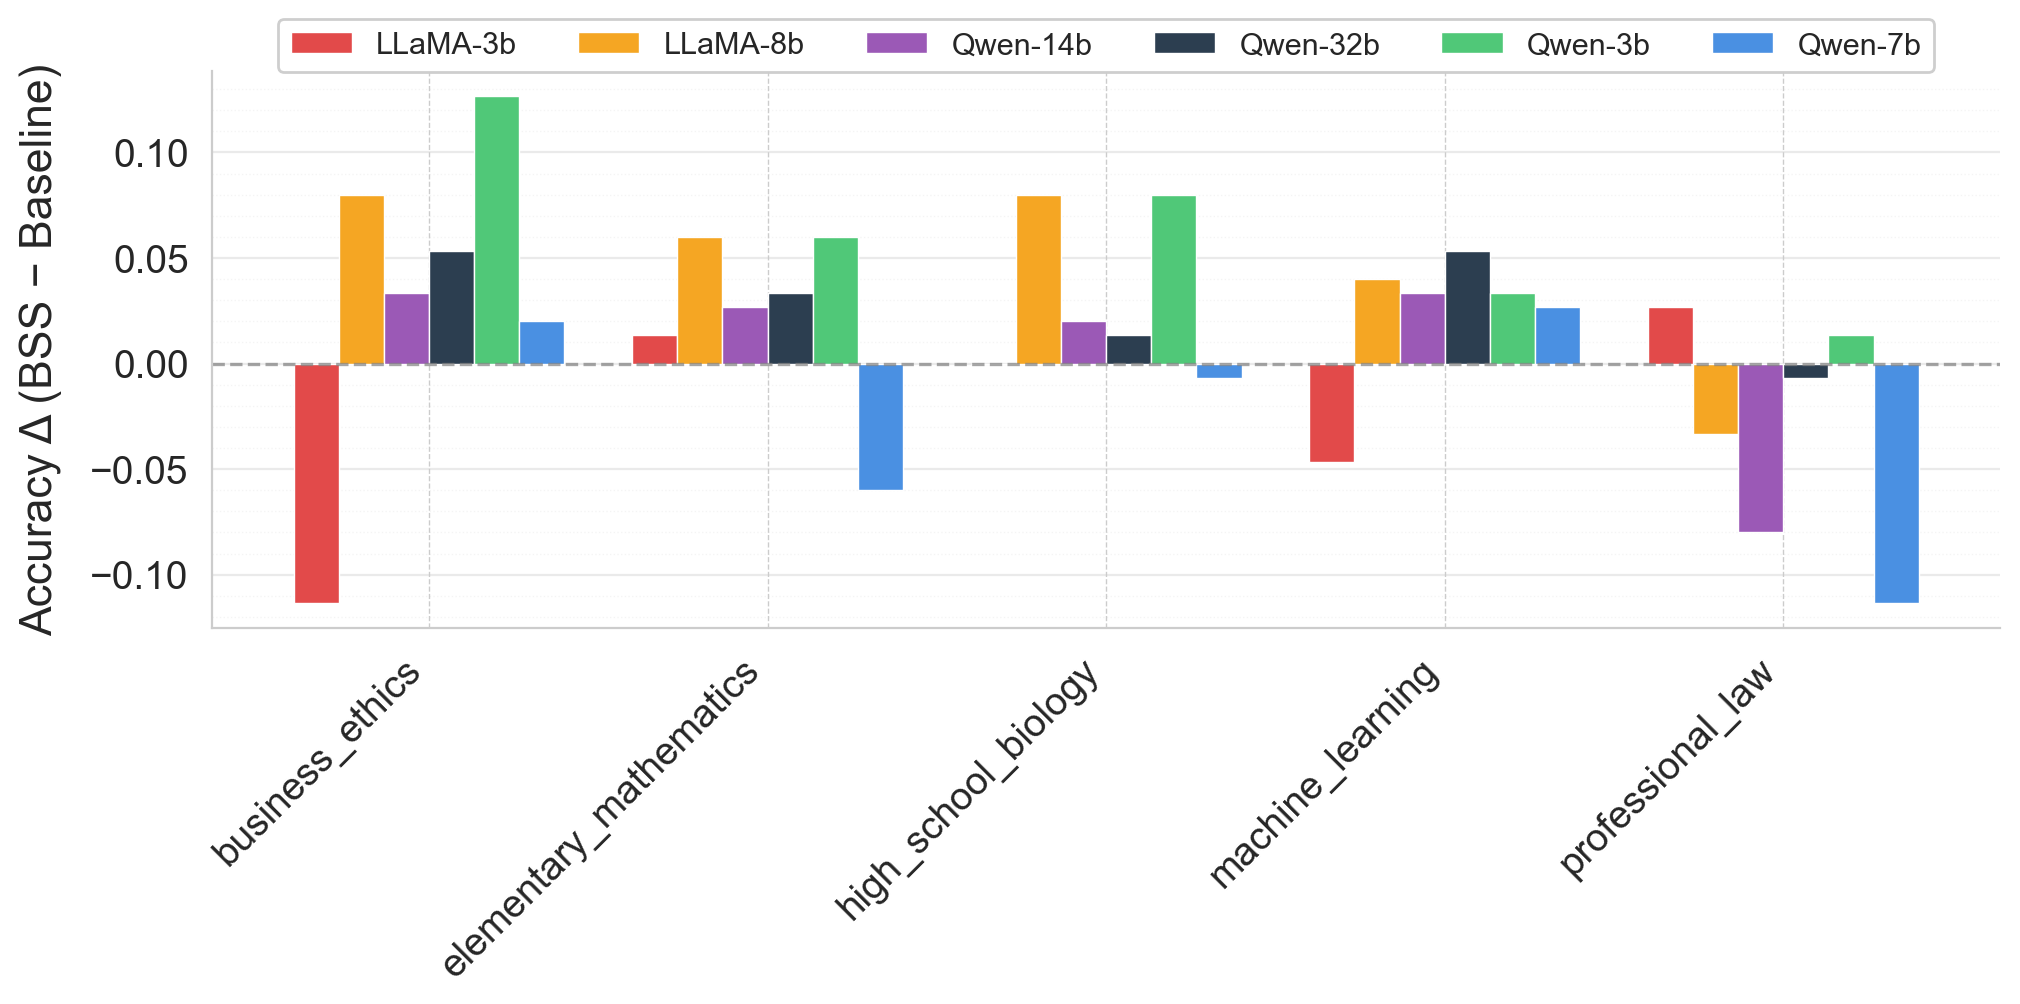

In [77]:
if "baseline" in subject_acc and "bss" in subject_acc:
    sa_base = subject_acc["baseline"]
    sa_bss = subject_acc["bss"]

    merged = sa_base.merge(sa_bss, on=["subject", "model"],
                           suffixes=("_base", "_bss"), how="inner")
    merged["delta"] = merged["accuracy_bss"] - merged["accuracy_base"]

    subjects = sorted(merged["subject"].unique())
    models = sorted(merged["model"].unique())

    fig, ax = plt.subplots(figsize=(max(12, len(subjects) * 0.9), 8.5))
    x = np.arange(len(subjects))
    width = 0.8 / max(len(models), 1)

    for i, model in enumerate(models):
        mdata = merged[merged["model"] == model].set_index("subject")
        deltas = [mdata.loc[s, "delta"] if s in mdata.index else 0 for s in subjects]
        model_display = model.replace("llama", "LLaMA-").replace("qwen", "Qwen-")
        ax.bar(x + i * width - 0.4 + width / 2, deltas, width,
               label=model_display, color=model_color(model), edgecolor="white", lw=0.5)

    ax.axhline(0, color="grey", ls="--", lw=1.2, alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(subjects, rotation=45, ha="right", fontsize=11)
    ax.set_ylabel("Accuracy Δ (BSS − Baseline)", fontsize=16, labelpad=10)
    
    # Fine-grained y-axis ticks
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.01))
    
    # Enhanced gridlines (major and minor)
    ax.grid(True, which="major", axis="y", linestyle="-", alpha=0.4, linewidth=0.8, zorder=0)
    ax.grid(True, which="minor", axis="y", linestyle=":", alpha=0.2, linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    
    ax.tick_params(labelsize=14, length=5, width=1.2)
    ax.legend(ncol=len(models), loc="upper center", bbox_to_anchor=(0.5, 1.12), framealpha=0.95)
    sns.despine()
    fig.tight_layout(rect=[0.14, 0.15, 1, 0.82])
    fig.savefig(FIGS_DIR / "subject_accuracy_delta.pdf")
    fig.savefig(FIGS_DIR / "subject_accuracy_delta.png")
    plt.show()
else:
    print("Need baseline and bss subject_accuracy.csv to plot this.")

## 12. Knowledge-Gated Accuracy

Accuracy restricted to samples where `knowledge_flags[model] == True` — i.e., the model "knew" the answer before debate.
Shows whether scores help models *hold onto* correct answers rather than being swayed.

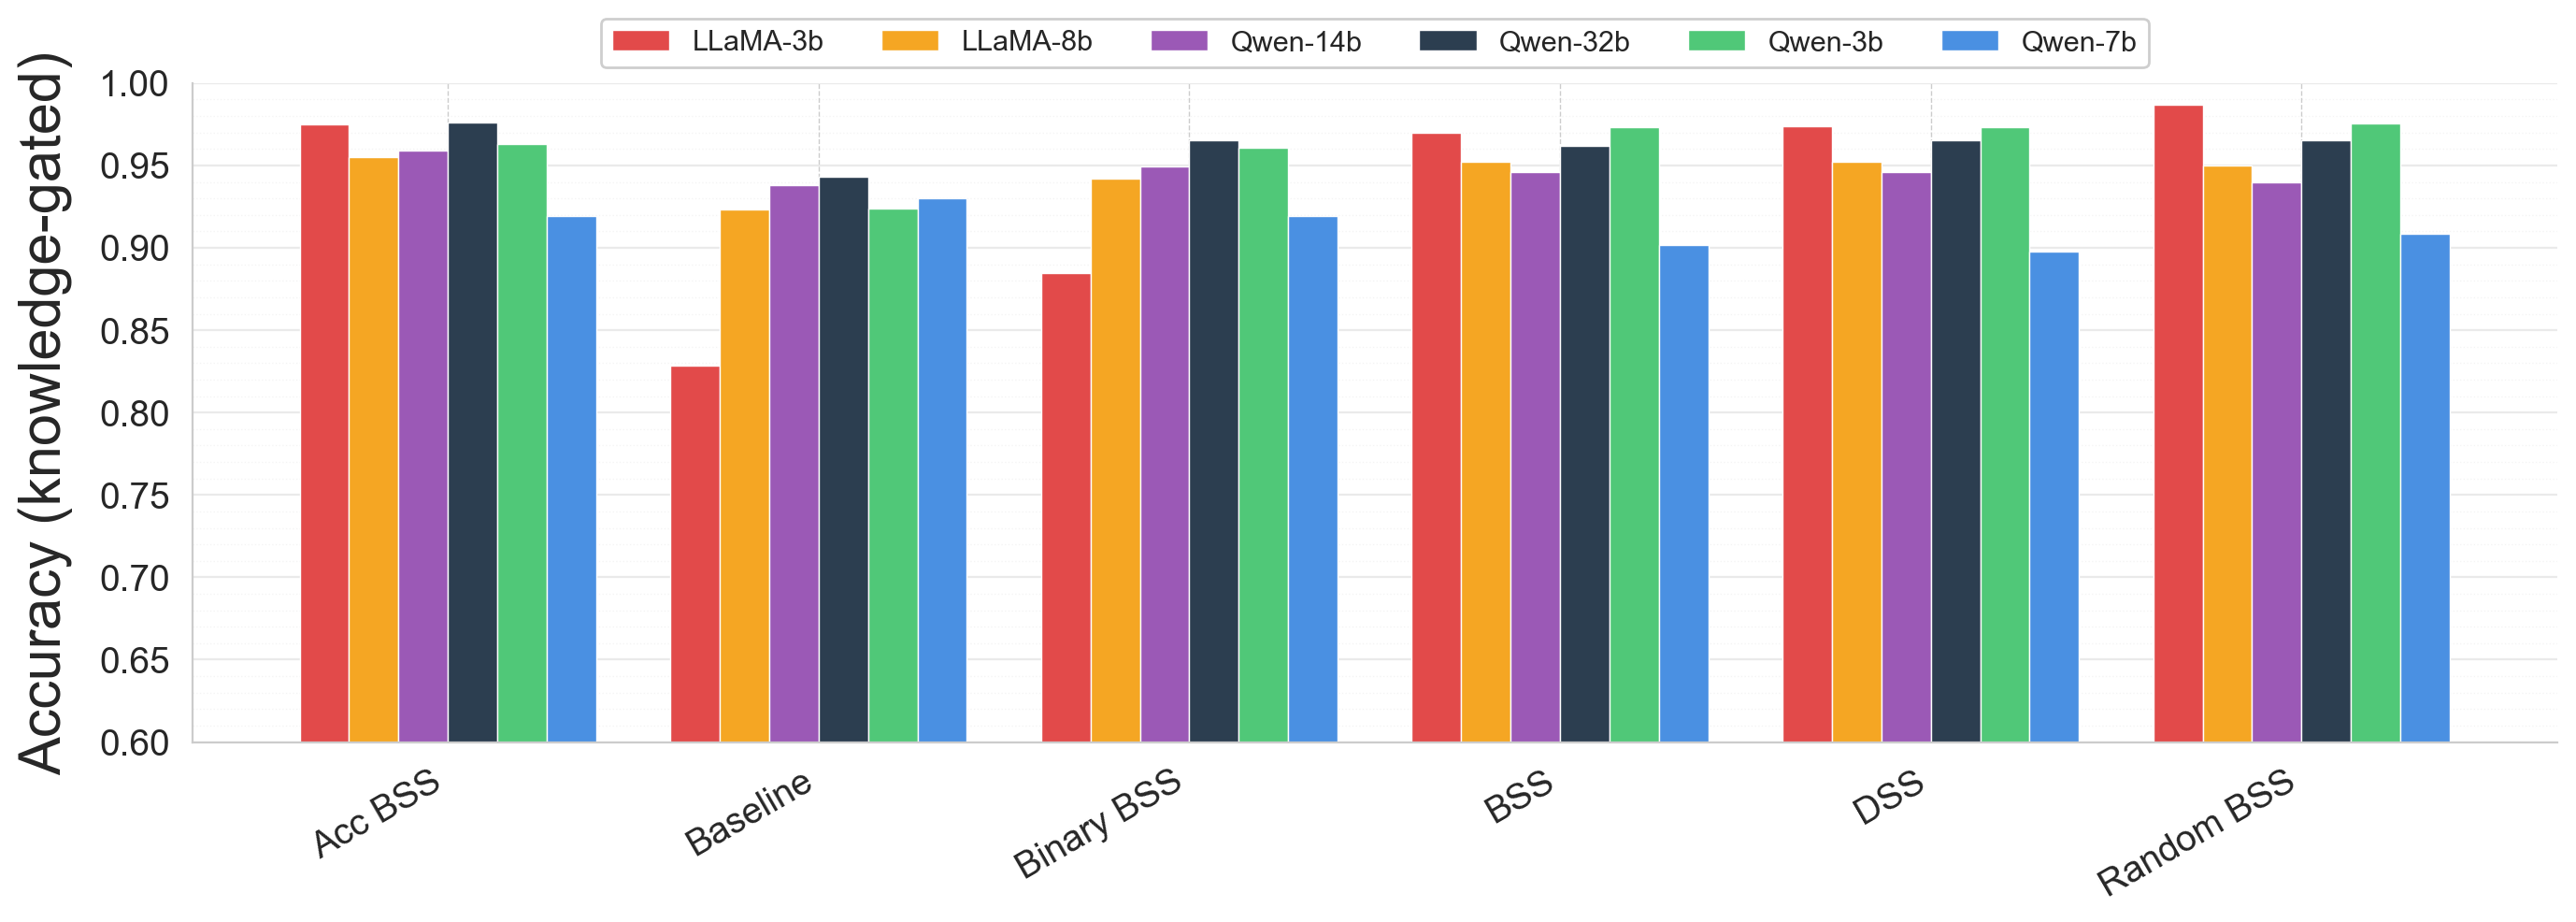

In [79]:
exps_kg = [e for e in EXPERIMENTS if e in knowledge_acc and not knowledge_acc[e].empty]
if exps_kg:
    kg_rows = []
    for exp in exps_kg:
        df = knowledge_acc[exp]
        for model, grp in df.groupby("model"):
            kg_rows.append({"experiment": exp, "model": model,
                            "accuracy": grp["is_correct"].mean(),
                            "n": len(grp)})
    kg_df = pd.DataFrame(kg_rows)
    models_kg = sorted(kg_df["model"].unique())

    fig, ax = plt.subplots(figsize=(14, 6.5))
    x = np.arange(len(exps_kg))
    width = 0.8 / max(len(models_kg), 1)

    for i, model in enumerate(models_kg):
        vals = []
        for exp in exps_kg:
            subset = kg_df[(kg_df["experiment"] == exp) & (kg_df["model"] == model)]
            vals.append(subset["accuracy"].values[0] if len(subset) else 0)
        ax.bar(x + i * width - 0.4 + width / 2, vals, width,
               label=model.replace("llama", "LLaMA-").replace("qwen", "Qwen-"), 
               color=model_color(model), edgecolor="white", lw=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels([NICE_NAMES.get(e, e) for e in exps_kg], rotation=30, ha="right", fontsize=14)
    ax.set_ylabel("Accuracy (knowledge-gated)", fontsize=22, labelpad=10)
    ax.set_ylim(0.6, 1.0)
    
    # Fine-grained y-axis ticks
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.01))
    
    # Enhanced gridlines (major and minor)
    ax.grid(True, which="major", axis="y", linestyle="-", alpha=0.4, linewidth=0.8, zorder=0)
    ax.grid(True, which="minor", axis="y", linestyle=":", alpha=0.2, linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    
    ax.tick_params(labelsize=14, length=5, width=1.2)
    ax.legend(ncol=len(models_kg), loc="upper center", bbox_to_anchor=(0.5, 1.12), framealpha=0.95)
    sns.despine()
    fig.tight_layout(rect=[0, 0, 1, 0.82])
    fig.savefig(FIGS_DIR / "knowledge_gated_accuracy.pdf")
    fig.savefig(FIGS_DIR / "knowledge_gated_accuracy.png")
    plt.show()
else:
    print("No knowledge_gated_accuracy.csv data found.")

## 13. Cumulative Flip Direction Over Rounds

Tracks how sycophantic vs correct flips accumulate as debate progresses. A healthy scoring mechanism should suppress sycophantic flips over rounds.

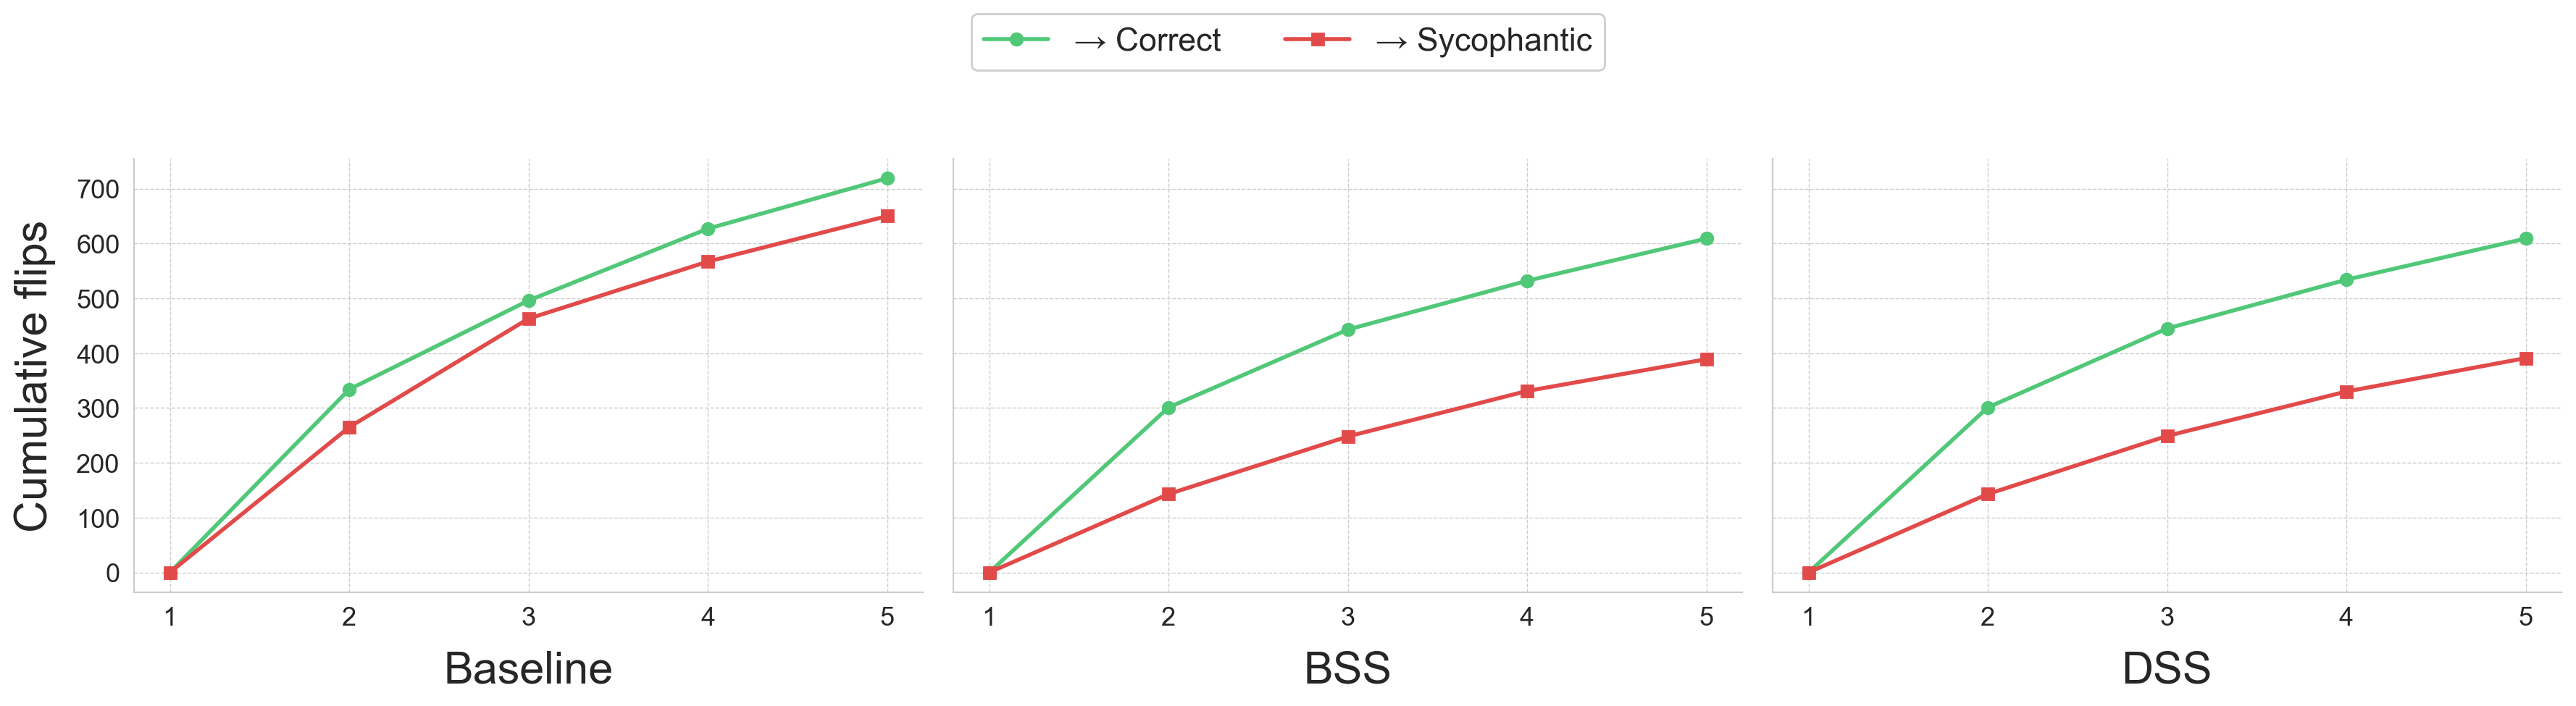

In [83]:
exps_flip_round = [e for e in ["baseline", "bss", "dss"] if e in flip_raw and not flip_raw[e].empty and "round" in flip_raw[e].columns]
if exps_flip_round:
    n_exps = len(exps_flip_round)
    fig, axes = plt.subplots(1, n_exps, figsize=(6 * n_exps, 5), sharey=True, squeeze=False)
    axes = axes.flatten()

    for idx, exp in enumerate(exps_flip_round):
        ax = axes[idx]
        df = flip_raw[exp].copy()
        if "round" not in df.columns:
            continue
        max_round = int(df["round"].max())
        rounds = list(range(1, max_round + 1))

        cum_correct = []
        cum_syco = []
        for r in rounds:
            sub = df[df["round"] <= r]
            cum_correct.append(sub["toward_correct"].sum() if "toward_correct" in sub.columns else 0)
            cum_syco.append(sub["toward_sycophantic"].sum() if "toward_sycophantic" in sub.columns else 0)

        ax.plot(rounds, cum_correct, marker="o", label="→ Correct", color="#50C878", lw=2)
        ax.plot(rounds, cum_syco, marker="s", label="→ Sycophantic", color="#E24A4A", lw=2)
        ax.set_xlabel(NICE_NAMES.get(exp, exp), fontsize=22, labelpad=10)
        if idx == 0:
            ax.set_ylabel("Cumulative flips", fontsize=22, labelpad=10)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        sns.despine(ax=ax)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=2, fontsize=16, **LEGEND_FIG_KW)

    fig.tight_layout(rect=[0, 0, 1, 0.82])
    fig.savefig(FIGS_DIR / "cumulative_flip_direction.pdf")
    fig.savefig(FIGS_DIR / "cumulative_flip_direction.png")
    plt.show()
else:
    print("No flip data with round info found.")


## 14. Flip Rate Breakdown by Direction (Per Model × Experiment)

For each model, compare the rate of flips toward **correct**, toward **majority**, and toward **sycophantic** across experiments.
This shows whether injecting scores shifts flip behavior in the right direction.

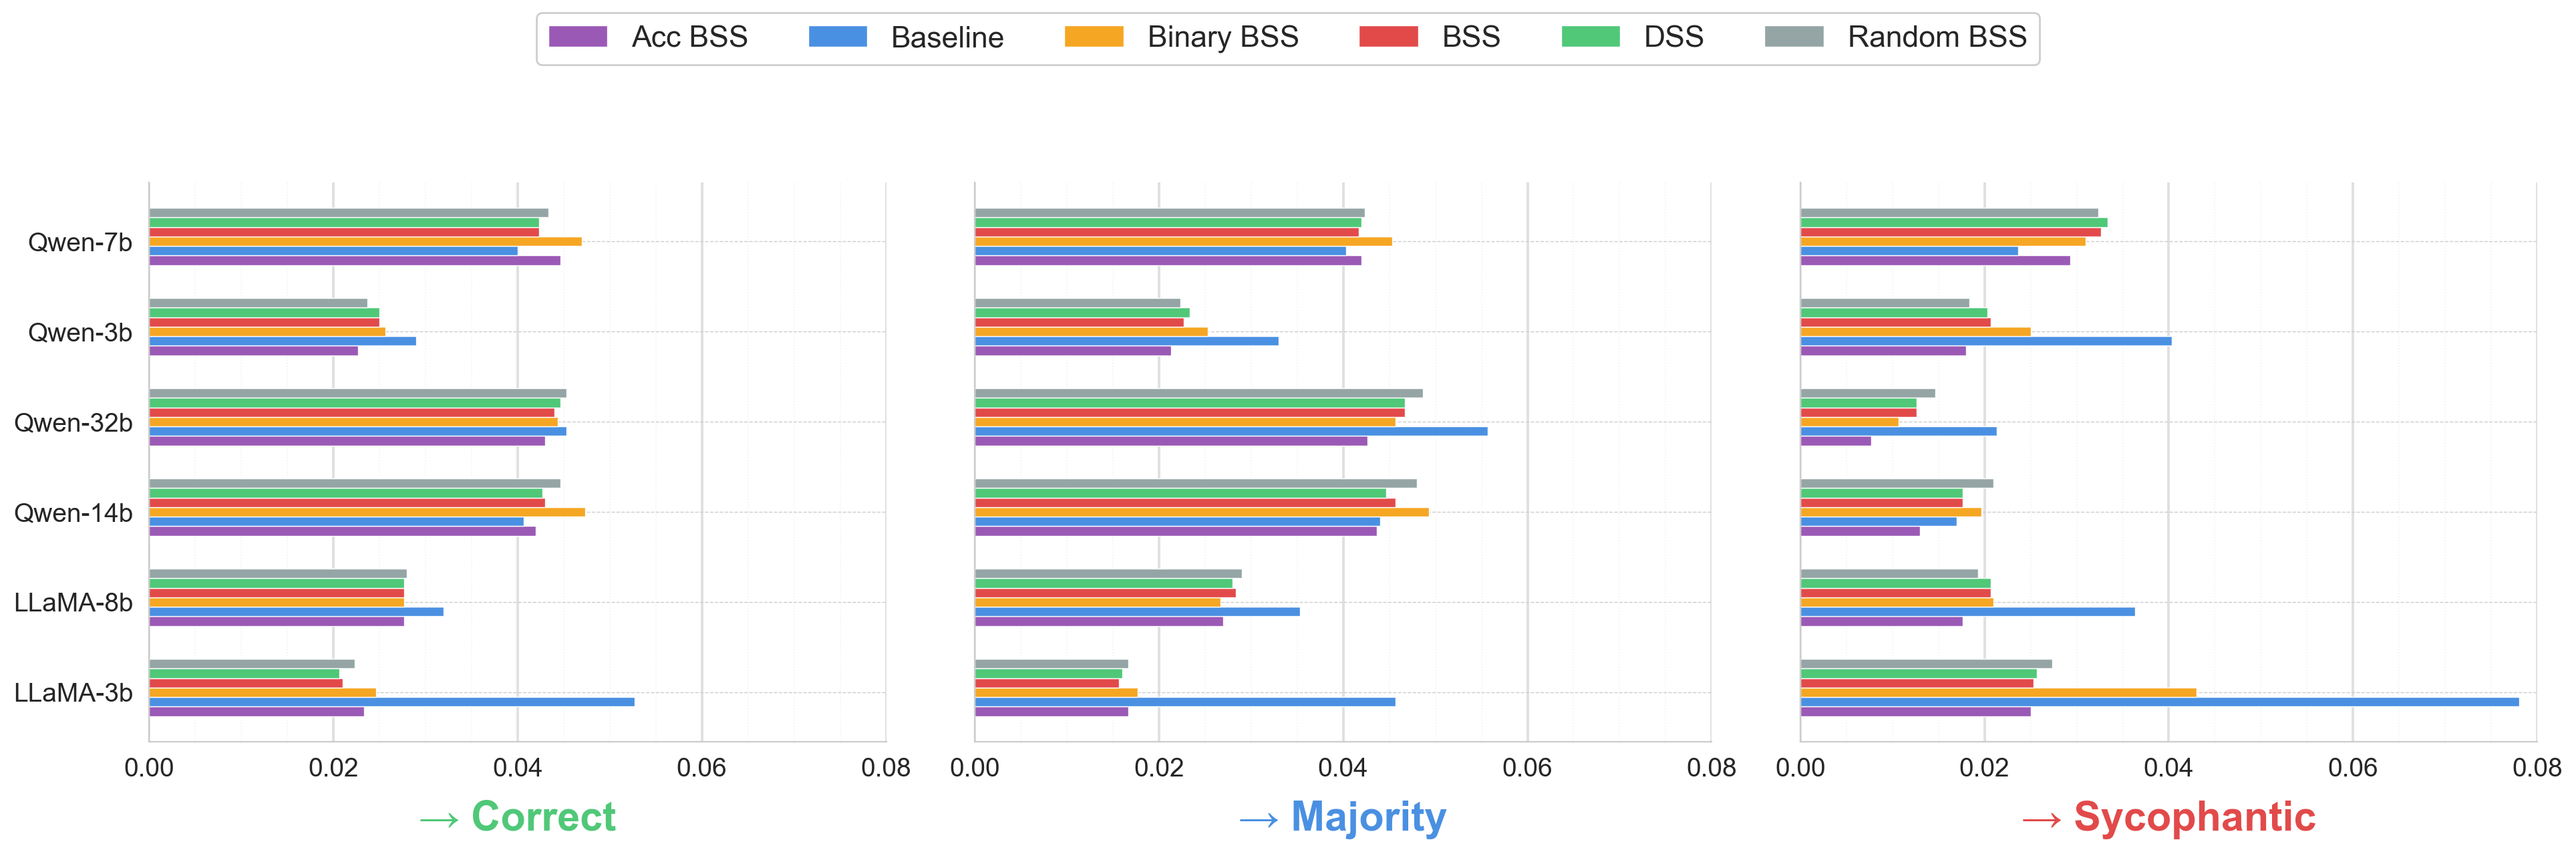

In [93]:
exps_fr = [e for e in EXPERIMENTS if e in flips and not flips[e].empty]
if exps_fr:
    directions = [
        ("toward_correct",      "→ Correct",      "#50C878"),
        ("toward_majority",     "→ Majority",      "#4A90E2"),
        ("toward_sycophantic",  "→ Sycophantic",   "#E24A4A"),
    ]

    rate_rows = []
    for exp in exps_fr:
        df = flips[exp].copy()
        for _, row in df.iterrows():
            model = row["model"]
            trans = row.get("transitions", 0)
            if trans == 0:
                continue
            for col, label, _ in directions:
                rate_rows.append({
                    "experiment": exp, "model": model,
                    "direction": label,
                    "rate": row[col] / trans,
                })
    rate_df = pd.DataFrame(rate_rows)

    models_list = sorted(rate_df["model"].unique())
    n_models = len(models_list)
    n_dirs = len(directions)

    fig, axes = plt.subplots(1, n_dirs, figsize=(6.5 * n_dirs, max(6.5, n_models * 0.9)),
                             sharey=True, squeeze=False)
    axes = axes.flatten()

    for d_idx, (col, label, base_color) in enumerate(directions):
        ax = axes[d_idx]
        sub = rate_df[rate_df["direction"] == label]
        y = np.arange(n_models) * 1.5
        bar_h = 0.95 / max(len(exps_fr), 1)

        for e_idx, exp in enumerate(exps_fr):
            edf = sub[sub["experiment"] == exp].set_index("model")
            vals = [edf.loc[m, "rate"] if m in edf.index else 0 for m in models_list]
            ax.barh(y + e_idx * bar_h - 0.4 + bar_h / 2, vals, bar_h,
                    label=NICE_NAMES.get(exp, exp), color=exp_color(exp),
                    edgecolor="white", lw=0.5)

        ax.set_yticks(y)
        ax.set_yticklabels([m.replace("llama", "LLaMA-").replace("qwen", "Qwen-") for m in models_list], fontsize=14)
        ax.set_xlabel(label, fontsize=22, labelpad=10, fontweight="bold", color=base_color)
        
        # Fine-grained gridlines
        ax.xaxis.set_major_locator(plt.MultipleLocator(0.02))
        ax.xaxis.set_minor_locator(plt.MultipleLocator(0.005))
        ax.grid(True, which="major", axis="x", linestyle="-", alpha=0.6, linewidth=1.4, zorder=0)
        ax.grid(True, which="minor", axis="x", linestyle=":", alpha=0.25, linewidth=0.6, zorder=0)
        ax.set_axisbelow(True)
        
        ax.tick_params(labelsize=14, length=5, width=1.2)
        ax.set_xlim(0, 0.08)
        sns.despine(ax=ax)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=len(exps_fr), fontsize=16, **LEGEND_FIG_KW)

    fig.tight_layout(rect=[0, 0, 1, 0.82])
    fig.subplots_adjust(wspace=0.12)
    fig.savefig(FIGS_DIR / "flip_rate_by_direction.pdf")
    fig.savefig(FIGS_DIR / "flip_rate_by_direction.png")
    plt.show()
else:
    print("No flip_summary data found.")


## 15. Round-1 vs Final and Stability

Plots from `round1_vs_final.csv` and `stability.csv` (run `analyze.py` first).

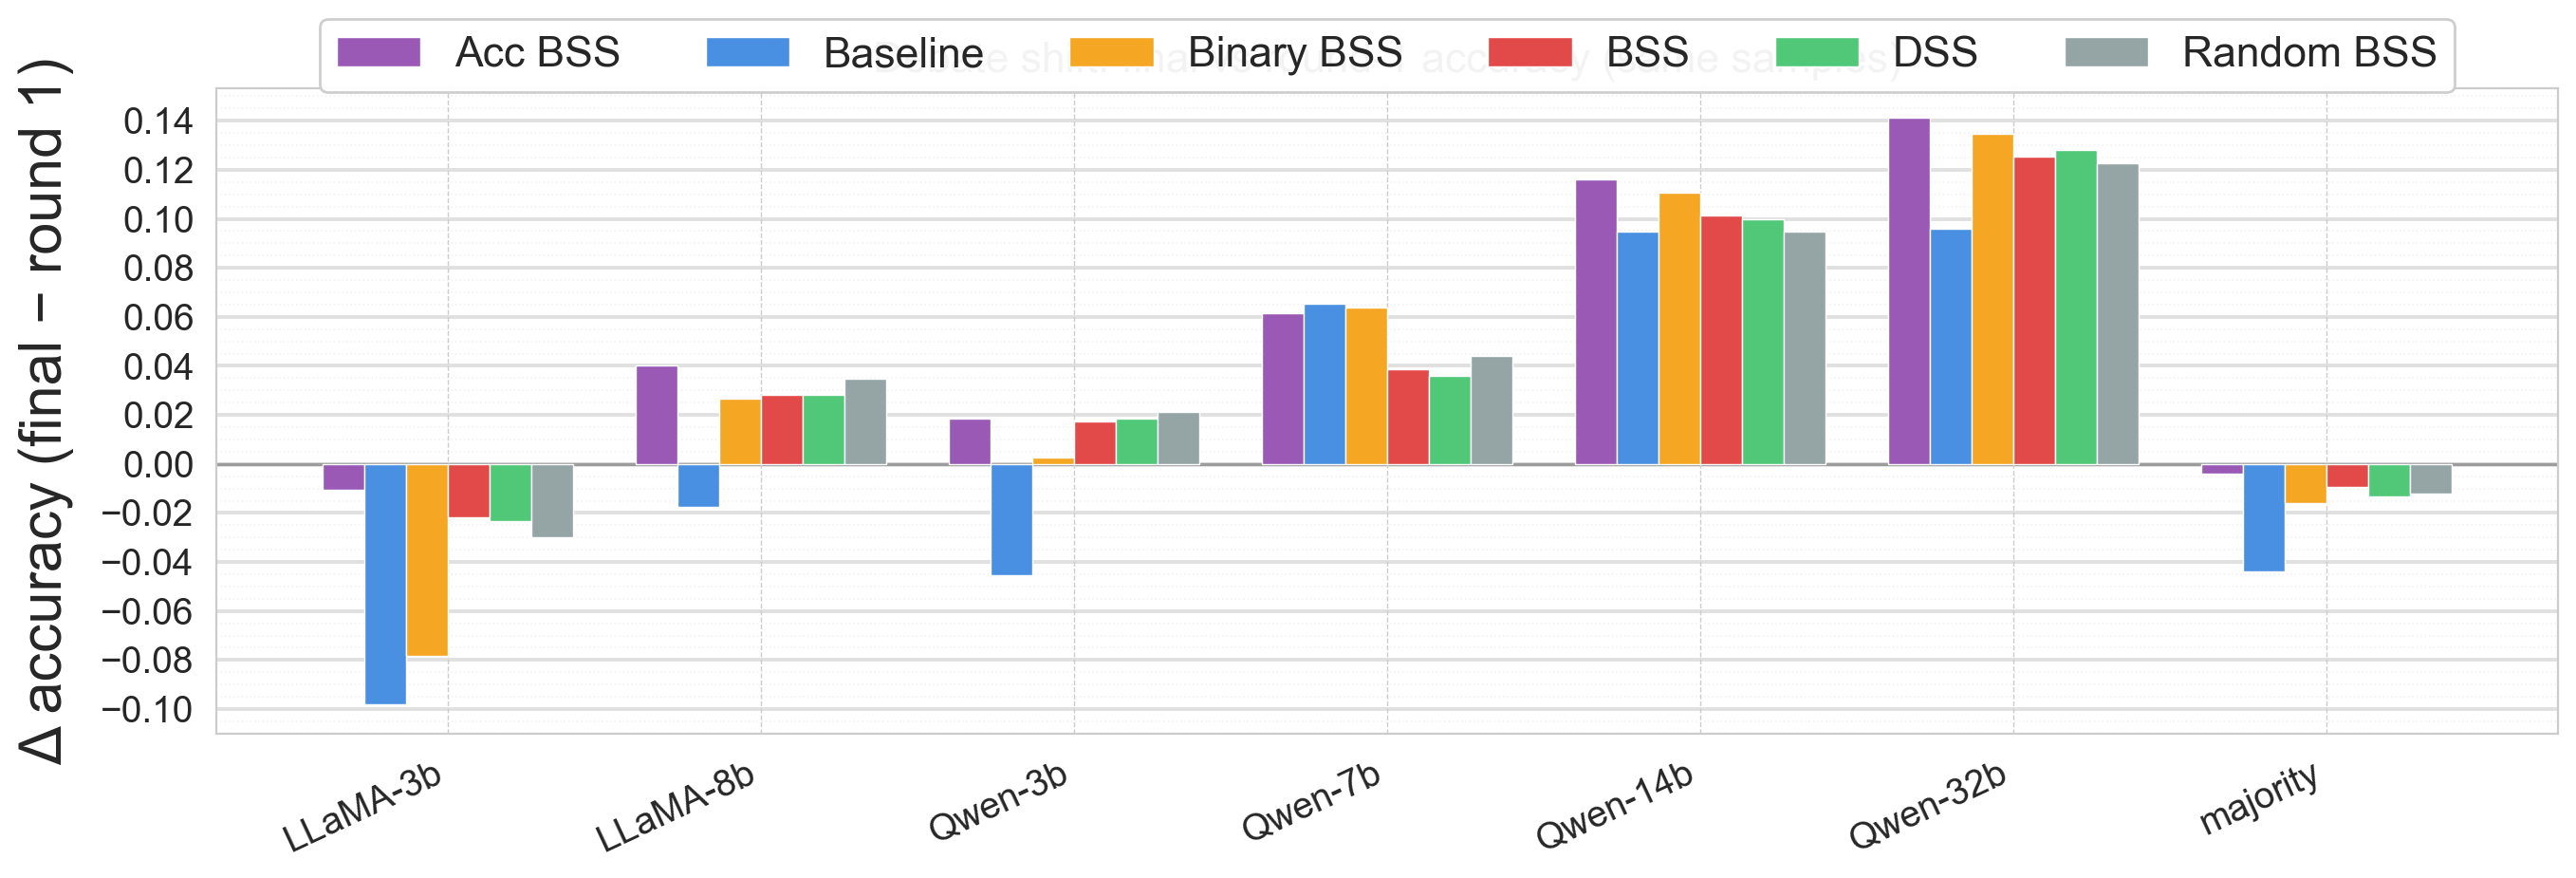

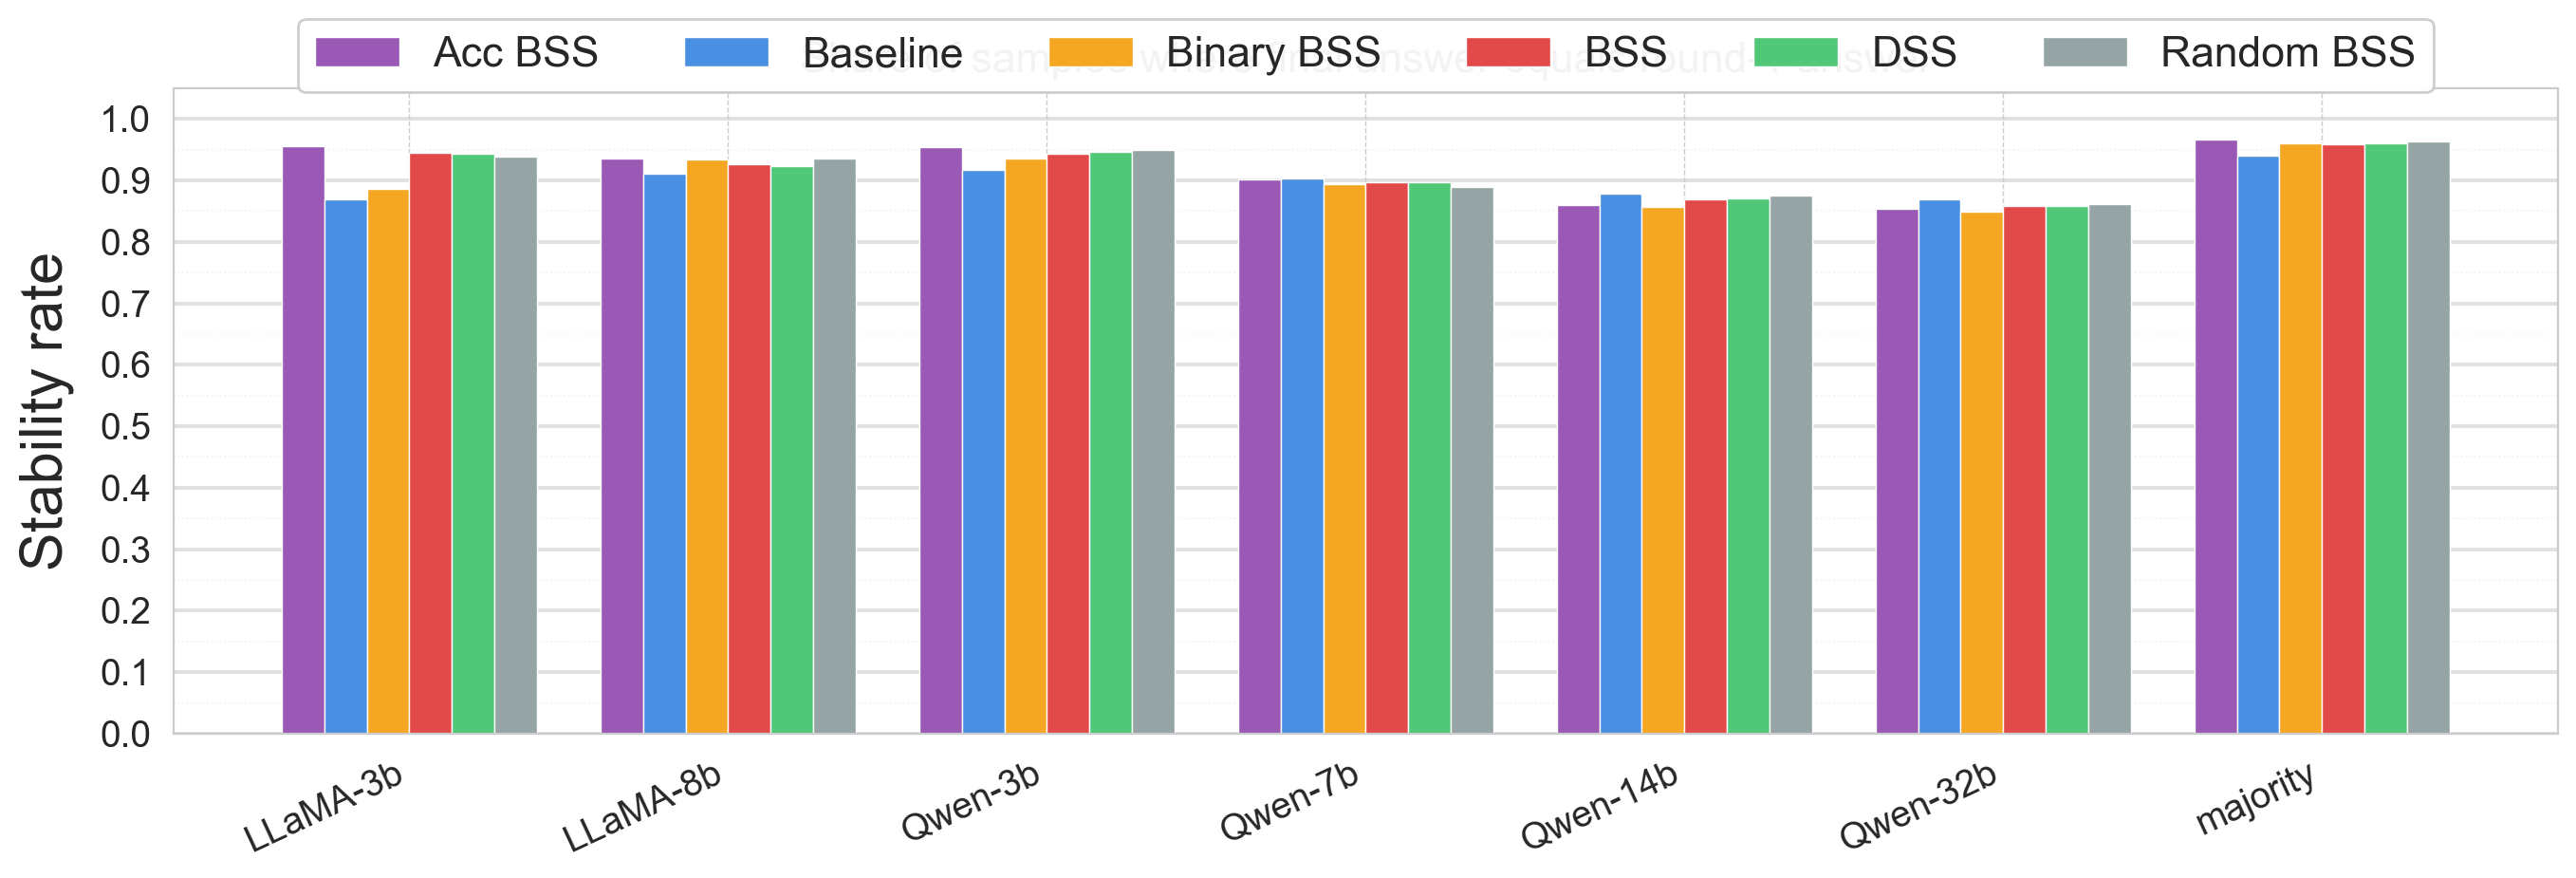

In [98]:
# --- Δ accuracy (final − round 1), same layout as accuracy comparison ---
exps_r1 = [e for e in EXPERIMENTS if e in round1_final and not round1_final[e].empty]
if exps_r1:
    rows = []
    for exp in exps_r1:
        for _, r in round1_final[exp].iterrows():
            rows.append({"experiment": exp, "model": r["model"], "delta": r["delta_final_minus_round1"]})
    delta_df = pd.DataFrame(rows)
    delta_df["model"] = pd.Categorical(delta_df["model"], categories=MODEL_ORDER, ordered=True)
    delta_df = delta_df.sort_values(["model", "experiment"])
    models_in_data = [m for m in MODEL_ORDER if m in delta_df["model"].unique()]
    x = np.arange(len(models_in_data))
    n_exp = len(exps_r1)
    width = 0.8 / n_exp
    fig, ax = plt.subplots(figsize=(14, 6.5))
    
    for i, exp in enumerate(exps_r1):
        exp_data = delta_df[delta_df["experiment"] == exp].set_index("model")
        vals = [exp_data.loc[m, "delta"] if m in exp_data.index else np.nan for m in models_in_data]
        ax.bar(x + i * width, vals, width, label=NICE_NAMES.get(exp, exp),
               color=exp_color(exp), edgecolor="white", linewidth=0.5)
    
    ax.axhline(0, color="0.35", lw=1.2, zorder=0)
    ax.set_xticks(x + width * (n_exp - 1) / 2)
    ax.set_xticklabels([m.replace("llama", "LLaMA-").replace("qwen", "Qwen-") for m in models_in_data], 
                      rotation=25, ha="right", fontsize=14)
    ax.set_ylabel("Δ accuracy (final − round 1)", fontsize=22, labelpad=10)
    ax.set_title("Debate shift: final vs round-1 accuracy (same samples)", fontsize=16)
    
    # Enhanced gridlines
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.02))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.005))
    ax.grid(True, which="major", axis="y", linestyle="-", alpha=0.6, linewidth=1.4, zorder=0)
    ax.grid(True, which="minor", axis="y", linestyle=":", alpha=0.25, linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    
    ax.tick_params(labelsize=14, length=5, width=1.2)
    ax.legend(**LEGEND_KW, ncol=n_exp, fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.78])
    fig.savefig(FIGS_DIR / "round1_vs_final_delta.pdf")
    fig.savefig(FIGS_DIR / "round1_vs_final_delta.png")
    plt.show()
else:
    print("No round1_vs_final.csv data (re-run analyze.py).")

# --- Stability rate (final answer equals round-1 answer) ---
exps_st = [e for e in EXPERIMENTS if e in stability and not stability[e].empty]
if exps_st:
    rows = []
    for exp in exps_st:
        for _, r in stability[exp].iterrows():
            rows.append({"experiment": exp, "model": r["model"], "stability_rate": r["stability_rate"]})
    stab_df = pd.DataFrame(rows)
    stab_df["model"] = pd.Categorical(stab_df["model"], categories=MODEL_ORDER, ordered=True)
    stab_df = stab_df.sort_values(["model", "experiment"])
    models_in_data = [m for m in MODEL_ORDER if m in stab_df["model"].unique()]
    x = np.arange(len(models_in_data))
    n_exp = len(exps_st)
    width = 0.8 / n_exp
    fig, ax = plt.subplots(figsize=(14, 6.5))
    
    for i, exp in enumerate(exps_st):
        exp_data = stab_df[stab_df["experiment"] == exp].set_index("model")
        vals = [exp_data.loc[m, "stability_rate"] if m in exp_data.index else np.nan for m in models_in_data]
        ax.bar(x + i * width, vals, width, label=NICE_NAMES.get(exp, exp),
               color=exp_color(exp), edgecolor="white", linewidth=0.5)
    
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x + width * (n_exp - 1) / 2)
    ax.set_xticklabels([m.replace("llama", "LLaMA-").replace("qwen", "Qwen-") for m in models_in_data], 
                      rotation=25, ha="right", fontsize=14)
    ax.set_ylabel("Stability rate", fontsize=22, labelpad=10)
    ax.set_title("Share of samples where final answer equals round-1 answer", fontsize=16)
    
    # Enhanced gridlines
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))
    ax.grid(True, which="major", axis="y", linestyle="-", alpha=0.6, linewidth=1.4, zorder=0)
    ax.grid(True, which="minor", axis="y", linestyle=":", alpha=0.25, linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    
    ax.tick_params(labelsize=14, length=5, width=1.2)
    ax.legend(**LEGEND_KW, ncol=n_exp, fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.78])
    fig.savefig(FIGS_DIR / "stability_rate.pdf")
    fig.savefig(FIGS_DIR / "stability_rate.png")
    plt.show()
else:
    print("No stability.csv data (re-run analyze.py).")